# Function 7

<b> Description of the Sample Application:</b> You’re tasked with optimising an ML model by tuning six hyperparameters, for example learning rate, regularisation strength or number of hidden layers. The function you’re maximising is the model’s performance score (such as accuracy or F1), but since the relationship between inputs and output isn’t known, it’s treated as a black-box function. 
Because this is a commonly used model, you might benefit from researching best practices or literature to guide your initial search space. Your goal is to find the combination of hyperparameters that yields the highest possible performance




## Change Log

| Date | Week | Changes Made |
|---|---|---|
| 22/07/2026 | Week 1 | 1. Initial Version with 10 Data Point |
| 22/07/2026 | Week 2 | 1. Added Change Log and Progress Log.<br>2. Added new data point. |
| 05/08/2026 | Week 3 | 1. Appended Week 2's input and output to the dataset.<br>2. Re-ran kernel comparison (RBF vs Matern) on the updated 32-point data set.<br>3. Lowered β from 1.2 to 0.8, continuing the shift toward exploitation.<br>4. Reused the consolidated bayesian_optimization_step() function unchanged.<br>7. Updated convergence and parallel-coordinates plots to include Week 2/3. |
| 13/08/2026 | Week 4 | 1. Appended Week-3 input and output data points.<br>2. **New**: restricted the acquisition search to a local neighbourhood around the current best point instead of the full unit cube.<br>3. **New**: Implemented Expected Improvement (EI) and compared it against UCB on that neighbourhood, since Weeks 2-3's global-UCB queries both underperformed the known best. |
| 20/08/2026 | Week 5 | 1. Appended Week-4 feedback point (34 points).<br>2. **New**: global multi-modality / variance scan across the full cub.<br>3. **Strategy change (evidence-driven)**: the scan's top candidates are *not* a second optimum — they differ from the current best almost entirely in **x3**, which the GP has declared irrelevant. The observed data contradicts this. Week 5 therefore constrains x3 to an empirically supported band rather than trusting the surrogate's flatness assumption.<br>4. Added diagnostic cells evidencing the mis-specification. |
| 02/09/2026 | Week 6 | Appended Week-5 points. New Best found: 1.596708. <br>**x3 band widened upward to [0.15, 0.50]**: Week 5's query landed exactly on the old upper edge (0.300) and y increases monotonically with x3 across clean high-y points. The constraint was capping the improvement direction.<br>**Search radius widened 0.15 → 0.20**: results still improving sharply; tightening now would risk premature convergence.<br>Search box now recentres on the *new* best point automatically.<br>**Defect fixes** carried over from Week 5: stale Y[:-3] convergence slice, incorrect Week-1 row in the progress log, and missing np.clip in format_submission. |
| 09/09/2026 | Week 7 | 1. Appended Week-6 point . Week 6's result(1.585074) is slightly below Week 5.<br>2. The x3 widening test returned a negative answer. The x3 optimum is now **bracketed**: 0.247->1.365, 0.300->1.597, 0.400->1.585.<br>3. **Strategy change: Stop widening, start bracketing.** A quadratic through the three bracket points puts the x3 peak at **0.348**; band set to **[0.28, 0.36]** around it, and x2 held near the best point's 0.342. Radius tightened **0.20 -> 0.12**.<br>4. Added a **leave-one-out robustness check** on the surrogate. |
| 16/09/2026 | Week 8 | 1. Appended Week-7 input/output. Result **1.109914 is a large drop.**<br>2. **Diagnosis by elimination:** The cause is x4 = 0.000, exactly on the domain boundary, not x3.<br>3. **The quadratic extrapolation failed** (predicted 1.589, actual 1.110): A 3-point fit was not enough evidence to justify moving away from the best-known configuration.<br>4. **New safeguard: explicit boundary floors** (EPS = 0.02) on every dimension.<br>5. Recentred tightly on the Week-5 best; radius 0.12 -> 0.08. |
| 23/09/2026 | Week 9 | 1. Appended Week-8 point. Recorded result is new project best: 1.646887.<br>2. **The single-variable method is validated**: x3 0.300 to 0.330 with everything else held fixed gave a cleanly attributable **+0.050179**.<br>3. **Surrogate recovery confirmed**: fitted noise fell 0.0999 → 1e-06, all six length-scales are finite again (x2/x3 no longer pinned), and LOO mean\|z\| improved 1.561→0.986.<br>4. **Strategy: continue the ladder** to x3 = 0.360 rather than take the EI-optimal point, which again drifts onto three box bounds.<br>5. The chosen query **double-tests the Week-8 diagnosis** by re-running Week 7's x3 = 0.360 with a safe x4. || 30/09/2026 | Week 10 | 1. Appended Week-9 input/output points. Result **1.698012 - third consecutive record.**<br>2. **x4 diagnosis confirmed by controlled pair**: same x3 = 0.360, x4 = 0.000 → 1.110 vs x4 = 0.088 → 1.698. **+0.588098 attributable to x4 alone.** <br>3. **Ladder is :** +0.050179, +0.051124 per 0.03 step. No flattening.<br>4. **Strategy change: Step size 0.03 → 0.12** (x3 → 0.48). With three queries left, the step scales up to convert the established trend into score while remaining single-variable. |


## Progress log

| Week | Query point (x1–x6) | Output (y) | Method | Notes |
|---|---|---|---|---|
|  |  |  |  |  |
| 1 | 0.039632-0.201121-0.140302-0.063997-0.319477-0.787730 | 1.331930 | GP (RBF) + UCB (β=2.0), random-sample search | Exploration-heavy first query; landed on the domain edge for x1, x2 |
| 2 | 0.000000-0.000000-1.000000-0.198783-0.377305-0.792654 | 0.909142 | GP (Matern 5/2, CV-selected) + UCB (β = 1.2) | Result: Lower than predicted (mean ≈ 1.40), the GP overestimated. x3 pinned at the domain edge |
| 3 | 0.000000-0.424949-0.000000-0.083071-0.363094-0.823966 | **0.793646** | GP (Matern, re-confirmed) + UCB (β=0.8) | Third query in a row below the known best (1.365); x1, x3 pinned at 0 again - global UCB keeps favouring boundary points that don't pay off |
| 4 | 0.007106-0.341672-0.097422-0.068118-0.366155-0.753175 | **1.102149** | GP (Matern) + **local** search (r=0.15), EI | **Best query result so far.** Local search clearly helped (0.794 → 1.102), though still below the Week-0 best and still over-predicted (1.503 vs 1.102) |
| 5 | 0.053813-0.341672-0.300000-0.088135-0.354691-0.745974 | **1.596708** | Local search + **x3 constrained to [0.05, 0.30]** | **New project best.** First result to beat the initial best (1.364968). The x3 diagnosis was correct - but the query landed on the band's *upper edge* |
| 6 | 0.067403-0.200000-0.400000-0.014328-0.338968-0.727934 | 1.585074 | Local (r=0.20) + x3 ∈ [0.15, 0.40] | **Test returned negative** — x3 = 0.400 did *not* improve on 0.300. Trend has topped out |
| 7 | 0.066356-0.390000-0.360000-**0.000000**-0.360831-0.753840 | 1.109914 | Local (r=0.12) + x3 bracket + quadratic vertex | **Large drop.** x4 sat exactly on the boundary |
| 8 | 0.053813-0.341672-**0.330000**-0.088135-0.354691-0.745974 | **1.646887** | **Single-variable step** from the Week-5 best (x3 only) + boundary floors | Surrogate noise term degraded; fine positioning not delegated to the model this round |
| 9 | 0.053813-0.341672-**0.360000**-0.088135-0.354691-0.745974 | **1.698012** | Single-variable step (x3 → 0.360) | Continues the ladder **and** re-tests Week 7's x3 with a safe x4 |
| 10 | - | - | Single-variable step, **larger stride** (x3 → 0.48) | Endgame: convert the linear trend into score with 3 queries left |

In [206]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import pdist
from sklearn.decomposition import PCA
from scipy.stats import norm
import warnings
warnings.filterwarnings("ignore")

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel, Matern
from sklearn.model_selection import KFold
from sklearn.model_selection import LeaveOneOut
from scipy.optimize import minimize
from plotting_utils import (
    plot_gp_1d, plot_acquisition_1d, plot_bo_iteration_1d,
    plot_convergence, plot_parallel_coordinates
)

# ---- Added for Weekly Dashboard ----
import matplotlib.gridspec as gridspec
C_LADDER   = "#2a78d6"   # slot 1, blue   - the controlled ladder
C_CONFOUND = "#eb6834"   # slot 2, orange - confounded observations
C_NEW      = "#1baf7a"   # slot 3, aqua   - this week's proposal
C_FAIL     = "#e34948"   # status red     - boundary failures (always labelled)
C_BG       = "#b8b7b0"   # recessive grey - background observations
GRID = dict(alpha=0.25, linewidth=0.6)

# Load and Analyse the Data

In [10]:
# File Names
input_file  = "initial_inputs.npy"
output_file = "initial_outputs.npy"

# Load the Files
X0      = np.load(input_file)
Y0      = np.load(output_file)


In [12]:
# New data from the first submission (example inputs and outputs)
X_w1_new_point = np.array([0.039632, 0.201121, 0.140302, 0.063997, 0.319477, 0.78773 ]   , dtype = np.float64)    # from input.txt
Y_w1_new_point = np.array([1.3319298110135898]                                           , dtype = np.float64)    # from output.txt

# New data from Week 2 submission
X_w2_new_point = np.array([0.      , 0.      , 1.      , 0.198783, 0.377305, 0.792654]   , dtype=np.float64)    # from input.txt
Y_w2_new_point = np.array([0.9091420611100625]                                           , dtype=np.float64)    # from output.txt

# New data from Week 3 submission
X_w3_new_point = np.array([0.      , 0.424949, 0.      , 0.083071, 0.363094, 0.823966]   , dtype=np.float64)   # from input.txt
Y_w3_new_point = np.array([0.7936458699948383]                                           , dtype=np.float64)   # from output.txt

# New data from Week 4 submission
X_w4_new_point = np.array([0.007106, 0.341672, 0.097422, 0.068118, 0.366155, 0.753175]   , dtype=np.float64)   # from input.txt
Y_w4_new_point = np.array([1.1021493276997398]                                           , dtype=np.float64)   # from output.txt

# New data from Week 5 submission
X_w5_new_point = np.array([0.053813, 0.341672, 0.3     , 0.088135, 0.354691, 0.745974]   , dtype=np.float64)   # from input.txt
Y_w5_new_point = np.array([1.5967078794764094]                                           , dtype=np.float64)   # from output.txt

# New data from Week 6 submission
X_w6_new_point = np.array([0.067403, 0.200000, 0.400000, 0.014328, 0.338968, 0.727934]   , dtype=np.float64)   # from input.txt
Y_w6_new_point = np.array([1.5850736240936802]                                           , dtype=np.float64)   # from output.txt

# New data from Week 7 submission
X_w7_new_point = np.array([0.066356, 0.390000, 0.360000, 0.000000, 0.360831, 0.753840]   , dtype=np.float64)   # from input.txt
Y_w7_new_point = np.array([1.1099137034142044]                                           , dtype=np.float64)   # from output.txt

# New data from Week 8 submission
X_w8_new_point = np.array([0.053813, 0.341672, 0.330000, 0.088135, 0.354691, 0.745974]   , dtype=np.float64)   # from input.txt
Y_w8_new_point = np.array([1.6468871406873669]                                           , dtype=np.float64)   # from output.txt

# New data from Week 9 submission
X_w9_new_point = np.array([0.053813, 0.341672, 0.360000, 0.088135, 0.354691, 0.745974]   , dtype=np.float64)   # from input.txt
Y_w9_new_point = np.array([1.6980115112532617]                                           , dtype=np.float64)   # from output.txt

In [14]:
# Append the new data points
X_updated      = np.vstack((X0, X_w1_new_point
                              , X_w2_new_point
                              , X_w3_new_point
                              , X_w4_new_point
                              , X_w5_new_point
                              , X_w6_new_point
                              , X_w7_new_point
                              , X_w8_new_point
                              , X_w9_new_point
                           ))
Y_updated      = np.append(Y0, [Y_w1_new_point
                             , Y_w2_new_point
                             , Y_w3_new_point
                             , Y_w4_new_point
                             , Y_w5_new_point
                             , Y_w6_new_point
                             , Y_w7_new_point
                             , Y_w8_new_point
                             , Y_w9_new_point
                              ])

In [16]:
print(X_updated)
print(Y_updated)

# Save the updated arrays
#np.save(r"initial_inputs.npy", X_updated)
#np.save(r"initial_outputs.npy", Y_updated)

[[0.27262382 0.32449536 0.89710881 0.83295115 0.15406269 0.79586362]
 [0.54300258 0.9246939  0.34156746 0.64648585 0.71844033 0.34313266]
 [0.09083225 0.66152938 0.06593091 0.25857701 0.96345285 0.6402654 ]
 [0.11886697 0.61505494 0.90581639 0.8553003  0.41363143 0.58523563]
 [0.63021764 0.8380969  0.68001305 0.73189509 0.52673671 0.34842921]
 [0.76491917 0.25588292 0.60908422 0.21807904 0.32294277 0.09579366]
 [0.05789554 0.49167222 0.24742222 0.21811844 0.42042833 0.73096984]
 [0.19525188 0.07922665 0.55458046 0.17056682 0.01494418 0.10703171]
 [0.64230298 0.83687455 0.02179269 0.10148801 0.68307083 0.6924164 ]
 [0.78994255 0.19554501 0.57562333 0.07365919 0.25904917 0.05109986]
 [0.52849733 0.45742436 0.36009569 0.36204551 0.81689098 0.63747637]
 [0.72261522 0.01181284 0.06364591 0.16517311 0.07924415 0.35995166]
 [0.07566492 0.33450212 0.13273274 0.60831236 0.91838592 0.82233079]
 [0.94245084 0.37743962 0.48612233 0.22879108 0.08263175 0.71195755]
 [0.14864702 0.03394336 0.72880565

In [18]:
# Assign X = X_updated and Y = Y_updated
X          = X_updated
Y          = Y_updated

# Analyse the Input Data
print("Input  Shape:", X.shape)
print("Inputs:\n", X)
print()

# Analyse the Output Data
print("Output Shape:", Y.shape)
print("Outputs:\n", Y)
print()

print(f"y Range: [: {Y.min()}, {Y.max()}]")
best_idx   = np.argmax(Y)
print(f"Best point: x = {X[best_idx]}, Y = {Y[best_idx]}")
print()

# Converting the Input and Output into a DataFram
df         = pd.DataFrame(X, columns = [f'X_{i+1}' for i in range(X.shape[1])])
df['Y'] = Y
print("Data Frame:\n", df)

Input  Shape: (39, 6)
Inputs:
 [[0.27262382 0.32449536 0.89710881 0.83295115 0.15406269 0.79586362]
 [0.54300258 0.9246939  0.34156746 0.64648585 0.71844033 0.34313266]
 [0.09083225 0.66152938 0.06593091 0.25857701 0.96345285 0.6402654 ]
 [0.11886697 0.61505494 0.90581639 0.8553003  0.41363143 0.58523563]
 [0.63021764 0.8380969  0.68001305 0.73189509 0.52673671 0.34842921]
 [0.76491917 0.25588292 0.60908422 0.21807904 0.32294277 0.09579366]
 [0.05789554 0.49167222 0.24742222 0.21811844 0.42042833 0.73096984]
 [0.19525188 0.07922665 0.55458046 0.17056682 0.01494418 0.10703171]
 [0.64230298 0.83687455 0.02179269 0.10148801 0.68307083 0.6924164 ]
 [0.78994255 0.19554501 0.57562333 0.07365919 0.25904917 0.05109986]
 [0.52849733 0.45742436 0.36009569 0.36204551 0.81689098 0.63747637]
 [0.72261522 0.01181284 0.06364591 0.16517311 0.07924415 0.35995166]
 [0.07566492 0.33450212 0.13273274 0.60831236 0.91838592 0.82233079]
 [0.94245084 0.37743962 0.48612233 0.22879108 0.08263175 0.71195755]
 [0

# Data Exploration

In [21]:
# Basic Staistics
print("Display Basic Statistics for the Dataset\n",df.describe())

Display Basic Statistics for the Dataset
              X_1        X_2        X_3        X_4        X_5        X_6  \
count  39.000000  39.000000  39.000000  39.000000  39.000000  39.000000   
mean    0.401730   0.370688   0.376307   0.412238   0.441177   0.549188   
std     0.333772   0.233452   0.305152   0.330982   0.279234   0.264170   
min     0.000000   0.000000   0.000000   0.000000   0.014944   0.051100   
25%     0.067007   0.200561   0.100385   0.112929   0.261781   0.354190   
50%     0.319810   0.341672   0.330000   0.285009   0.363094   0.640265   
75%     0.724450   0.505885   0.592354   0.744094   0.687320   0.745974   
max     0.942451   0.924694   1.000000   0.961017   0.998655   0.951014   

               Y  
count  39.000000  
mean    0.470812  
std     0.559015  
min     0.002701  
25%     0.027454  
50%     0.206310  
75%     0.734394  
max     1.698012  


In [23]:
# Check for Missing Values in the Data Set
print("Missing Values in the Dataset\n",df.isnull().sum())


Missing Values in the Dataset
 X_1    0
X_2    0
X_3    0
X_4    0
X_5    0
X_6    0
Y      0
dtype: int64


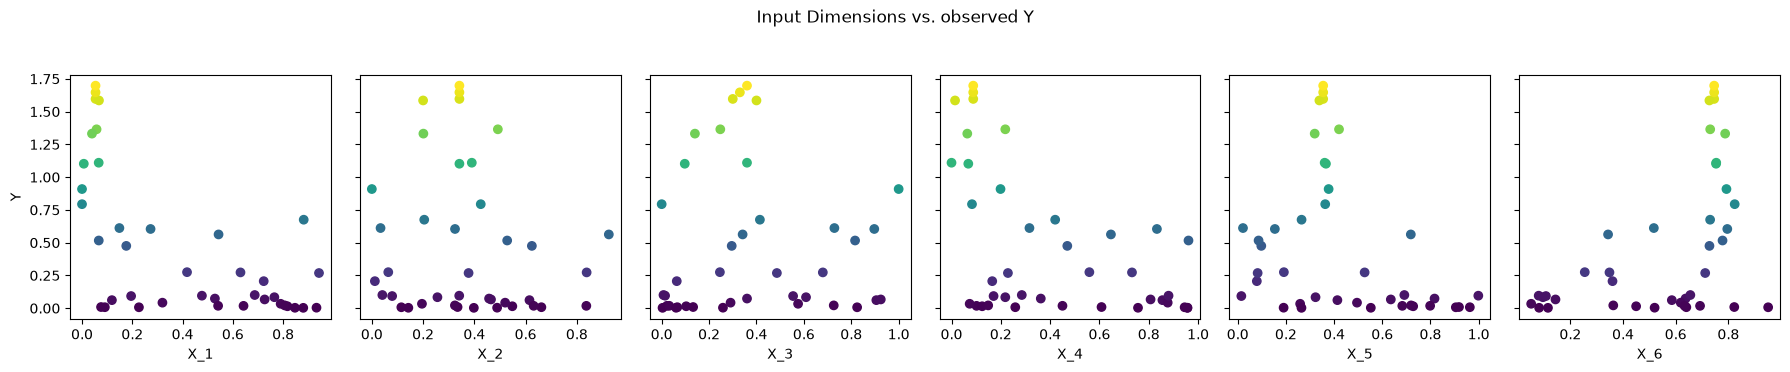

In [25]:
# Pairwise Scatter Plot, showing relationship of y for each input

fig, axes = plt.subplots(1, X.shape[1], figsize = (3 * X.shape[1], 3.5), sharey = True)
for ax, col in zip(axes, ['X_1','X_2','X_3','X_4','X_5','X_6']):
    ax.scatter(df[col], df['Y'], c = df['Y'], cmap = "viridis")
    ax.set_xlabel(col)
axes[0].set_ylabel('Y')
plt.suptitle("Input Dimensions vs. observed Y", y = 1.05)
plt.tight_layout()
plt.show()

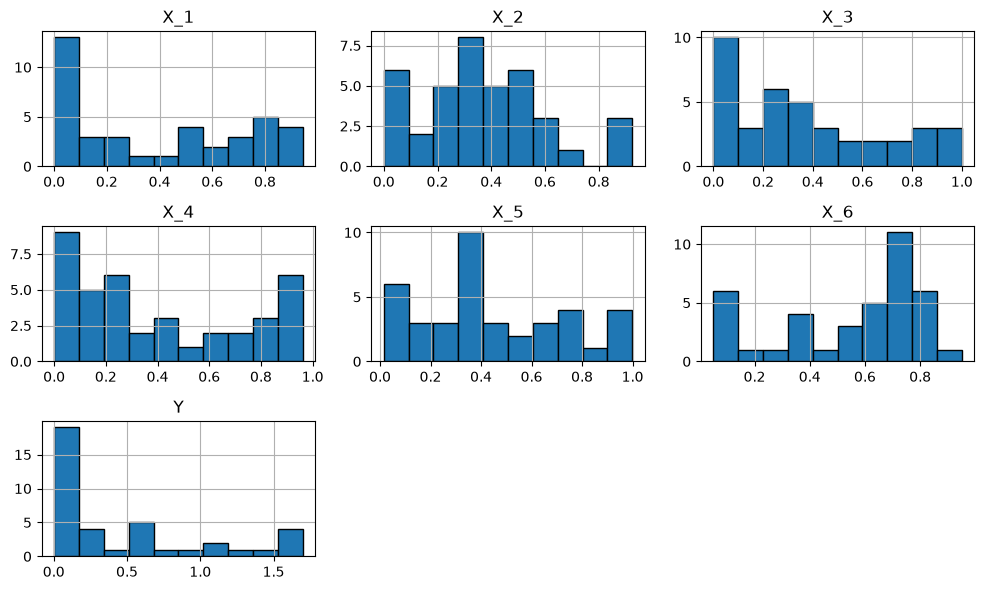

In [27]:
# Plot Histogram Visualisation for the columns of the DataFrame
df.hist(figsize = (10, 6), bins = 10, edgecolor = 'k' )
plt.tight_layout()
plt.show()

In [29]:
# Understanding Correlation between each input with y
labels      = ["X_1", "X_2", "X_3", "X_4", "X_5", "X_6"]
print("Correlation of each input with y:\n")

for i, lab in enumerate(labels):
    corr = np.corrcoef(X[:, i], Y)[0, 1]
    print(f" corr({lab}, Y) = {corr}")

Correlation of each input with y:

 corr(X_1, Y) = -0.6252997172912399
 corr(X_2, Y) = -0.13517808341847753
 corr(X_3, Y) = 0.0037271520419681304
 corr(X_4, Y) = -0.5030441197259401
 corr(X_5, Y) = -0.32570301198250573
 corr(X_6, Y) = 0.4949582989184718


<Axes: >

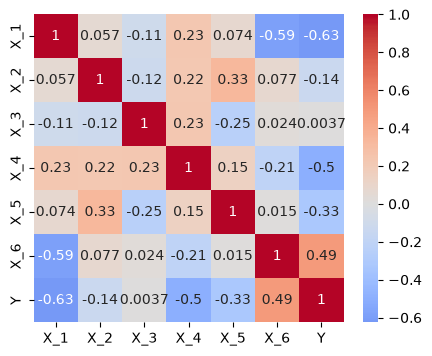

In [31]:
# Plotting the Correlation heatmap
plt.figure(figsize = (5, 4))
sns.heatmap(df.corr(), annot = True, cmap = "coolwarm", center = 0)

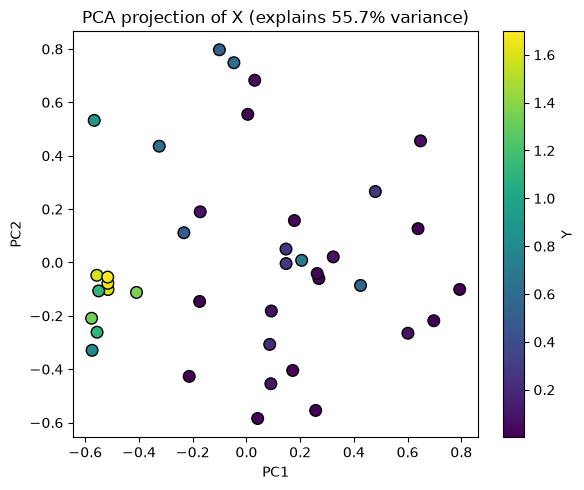

In [33]:
# Identify clustering of high-y points using PCA projection to 2D
pca  = PCA(n_components = 2)
X2   = pca.fit_transform(X)
plt.figure(figsize = (6, 5))
sc   = plt.scatter(X2[:, 0], X2[:, 1], c = Y, cmap = "viridis", s = 70, edgecolor = "k")
plt.colorbar(sc, label = "Y")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"PCA projection of X (explains {pca.explained_variance_ratio_.sum() * 100:.1f}% variance)")
plt.tight_layout()

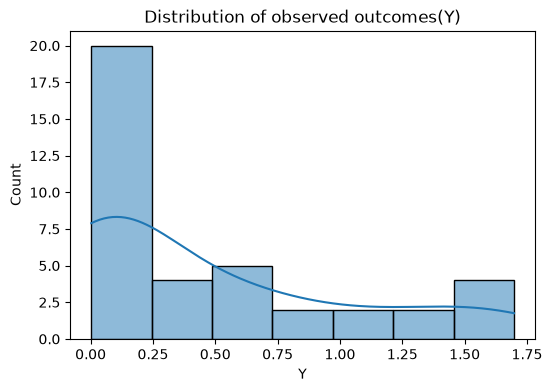

In [35]:
# Plot the Histogram for y to check for Outliers
plt.figure(figsize = (6,4))
sns.histplot(df['Y'], kde = True)
plt.title("Distribution of observed outcomes(Y)")
plt.show()

# Initialize Gaussian Process

In [38]:
#Define the kernel and initialise the GP model

kernel_rbf = ConstantKernel(1.0, (1e-2, 1e2)) * RBF(length_scale = np.ones(6), length_scale_bounds = (1e-2, 1e1)) \
                + WhiteKernel(noise_level = 1e-2, noise_level_bounds = (1e-6, 1e0))
gpr   = GaussianProcessRegressor(kernel = kernel_rbf, normalize_y = False, n_restarts_optimizer = 10, random_state = 42 )

# Fit the Gaussian Processes to existing data

In [41]:
# Train the model

gpr.fit(X, Y)
print("Learned kernel: ", gpr.kernel_)

Learned kernel:  0.42**2 * RBF(length_scale=[0.673, 0.418, 0.522, 0.217, 0.305, 0.44]) + WhiteKernel(noise_level=5.28e-06)


# Compute the UCB acquisition function

- UCB(x)=μ(x)+β⋅σ(x)
- A high beta favors exploration (uncertainty) over exploitation (predicted mean).
- Week 1 uses beta = 2.5, reflecting the 90:10 exploration-heavy strategy.

In [45]:
# Setting a higher beta(= 2.0) for Week -1
beta         = 2.0

# Function to calculatee UCB 
def ucb(X_query, gpr, beta):
    mu, std  = gpr.predict(X_query, return_std = True)
    return mu + beta * std

rng          = np.random.default_rng(42)
candidates   = rng.uniform(0, 1, size = (20000, 6))

ucb_values   = ucb(candidates, gpr, beta)
best_ucb_idx = np.argmax(ucb_values)
next_point   = candidates[best_ucb_idx]

print(f"Suggested next Query Point: {next_point}")
print(f"UCB Score: {ucb_values[best_ucb_idx]:.6e}")

Suggested next Query Point: [0.30770224 0.21712626 0.58424013 0.12323622 0.33932037 0.84940223]
UCB Score: 2.120252e+00


# Week 2: Kernel Comparison
RBF assumes an infinitely 
smooth surfac.; Matern is typically a better match for ML-performance landscape2). Both kernels are compared here with 5-fold cross-validated predicti e
log-likelihood t (31-pont) data et, and the better one selected.ook.

In [48]:
DIM   = 6
def make_gpr(kernel):
    k = ConstantKernel(1.0, (1e-2, 1e2)) * kernel + WhiteKernel(noise_level = 1e-2, noise_level_bounds = (1e-6, 1e0))
    return GaussianProcessRegressor(kernel = k, normalize_y = True, n_restarts_optimizer = 8, random_state = 0)

kernel_options = {  
    "RBF":            RBF(length_scale = np.ones(DIM), length_scale_bounds = (1e-2, 1e1)),
    "Matern(nu = 2.5)": Matern(length_scale = np.ones(DIM), length_scale_bounds = (1e-2, 1e1), nu = 2.5),
}

kf = KFold(n_splits = 5, shuffle = True, random_state = 0)
cv_scores = {}
for name, kern in kernel_options.items():
    lls   = []
    for tr_idx, te_idx in kf.split(X):
        gp_tmp = make_gpr(kern)
        gp_tmp.fit(X[tr_idx], Y[tr_idx])
        mu, sigma = gp_tmp.predict(X[te_idx], return_std = True)
        sigma     = np.maximum(sigma, 1e-6)
        ll        = -0.5 * np.log(2 * np.pi * sigma**2) - 0.5 * ((Y[te_idx] - mu)**2) / sigma**2
        lls.append(ll.mean())
    cv_scores[name] = np.mean(lls)
    print(f"  {name:16s}: CV log-likelihood = {cv_scores[name]:+.3f}")

best_kernel_name = max(cv_scores, key = cv_scores.get)
chosen_kernel = kernel_options[best_kernel_name]
print(f"\nSelected kernel for Week 5: {best_kernel_name}")

gp = make_gpr(chosen_kernel)
gp.fit(X, Y)
print(f"\nLearned kernel:\n{gp.kernel_}")

  RBF             : CV log-likelihood = -4.172
  Matern(nu = 2.5): CV log-likelihood = -2.448

Selected kernel for Week 5: Matern(nu = 2.5)

Learned kernel:
0.742**2 * Matern(length_scale=[0.606, 0.471, 0.617, 0.234, 0.307, 0.434], nu=2.5) + WhiteKernel(noise_level=2.38e-05)


# Week2: Bayesian Optimisation Function

In [50]:
def bayesian_optimization_step(X, Y, kernel, beta = 2.0, n_candidates = 20000, n_restarts = 40, use_optimizer = True, seed = 7):
    
    rng    = np.random.default_rng(seed)
    n_dims = X.shape[1]
    bounds = [(0.0, 1.0)] * n_dims

    k = ConstantKernel(1.0, (1e-2, 1e2)) * kernel + WhiteKernel(noise_level = 1e-2, noise_level_bounds = (1e-6, 1e0))
    gp = GaussianProcessRegressor(kernel = k, normalize_y = True, n_restarts_optimizer=8, random_state = 0)
    gp.fit(X, Y)

    def ucb(pts):
        mu, sigma = gp.predict(np.atleast_2d(pts), return_std = True)
        return mu + beta * sigma

    # Evaluate a random candidate set
    candidates       = rng.uniform(0, 1, size = (n_candidates, n_dims))
    candidate_ucb    = ucb(candidates)
    best_idx         = np.argmax(candidate_ucb)
    next_x, next_ucb = candidates[best_idx], candidate_ucb[best_idx]

    if use_optimizer:
        starts   = rng.uniform(0, 1, size = (n_restarts, n_dims))
        best_val = -next_ucb
        for x0 in starts:
            res  = minimize(lambda x: -ucb(x)[0], x0, method = "L-BFGS-B", bounds = bounds)
            if res.fun < best_val:
                best_val, next_x = res.fun, res.x
        next_x   = np.clip(next_x, 0.0, 1.0)
        next_ucb = ucb(next_x)[0]

    return {
        "gp": gp, "next_x": next_x, "next_ucb": next_ucb,
        "candidates": candidates, "candidate_ucb": candidate_ucb,
    }


In [51]:
# Week 2: Calling the Bayesian Optimisation Function
beta   = 1.2       # In week 2, beta is lowered from 2.0 to 1.2

result = bayesian_optimization_step(X, Y, chosen_kernel, beta = beta, n_candidates = 20000, n_restarts = 40, seed = 7)
gp = result["gp"]
next_x = result["next_x"]

mu_next, sigma_next = gp.predict(next_x.reshape(1, -1), return_std = True)

print(f"Kernel used   : {best_kernel_name}")
print(f"β             : {beta}")
print(f"Next point    : {np.round(next_x, 6)}")
print(f"Predicted mean: {mu_next[0]:.4f}   std: {sigma_next[0]:.4f}   UCB: {result['next_ucb']:.4f}")


Kernel used   : Matern(nu = 2.5)
β             : 1.2
Next point    : [0.       0.230572 0.497877 0.142614 0.340301 0.727262]
Predicted mean: 1.9352   std: 0.1240   UCB: 2.0840


# Week 3: Calling the Bayesian Optimisation Function

In [53]:
# Week 3: beta lowered from 1.2 to 0.8 
beta   = 0.8

result = bayesian_optimization_step(X, Y, chosen_kernel, beta=beta, n_candidates=20000,
                                     n_restarts=40, seed=7)
gp     = result["gp"]
next_x = result["next_x"]

mu_next, sigma_next = gp.predict(next_x.reshape(1, -1), return_std=True)

print(f"Kernel used   : {best_kernel_name}")
print(f"beta          : {beta}")
print(f"Next point    : {np.round(next_x, 6)}")
print(f"Predicted mean: {mu_next[0]:.4f}   std: {sigma_next[0]:.4f}   UCB: {result['next_ucb']:.4f}")

Kernel used   : Matern(nu = 2.5)
beta          : 0.8
Next point    : [0.       0.238523 0.497257 0.136674 0.342865 0.731702]
Predicted mean: 1.9445   std: 0.1148   UCB: 2.0363


# Perform Visualisation

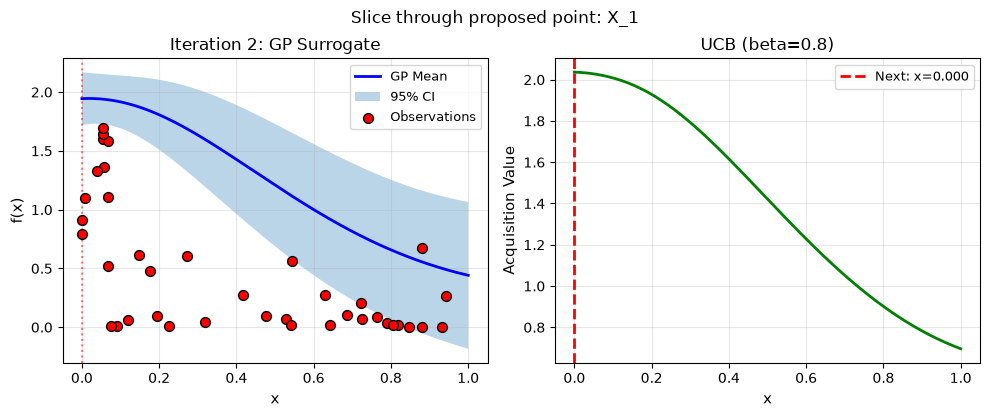

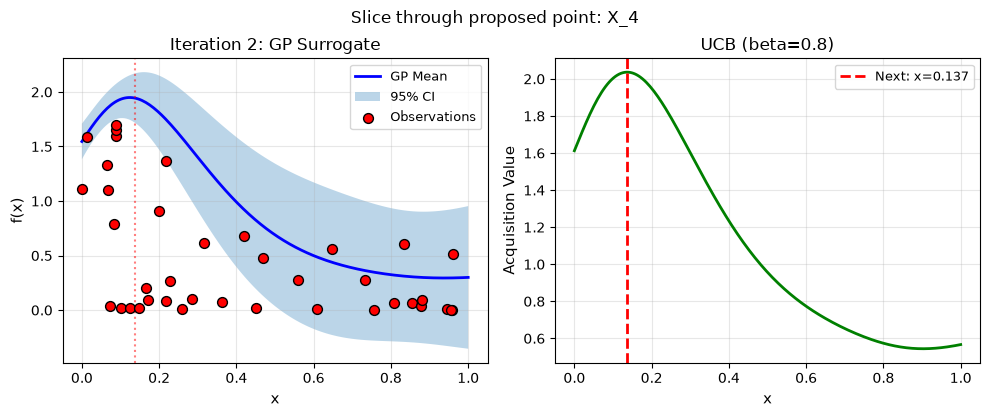

In [55]:
corrs    = [abs(np.corrcoef(X[:, i], Y)[0, 1]) for i in range(DIM)]
top_dims = np.argsort(corrs)[-2:][::-1]
grid     = np.linspace(0, 1, 200).reshape(-1, 1)

for d in top_dims:
    Xg            = np.tile(next_x, (len(grid), 1))
    Xg[:, d]      = grid.ravel()
    mu_g, sigma_g = gp.predict(Xg, return_std = True)
    ucb_g         = mu_g + beta * sigma_g

    fig, (ax1, ax2) = plot_bo_iteration_1d(
        X_train=X[:, d].reshape(-1, 1), y_train = Y,
        X_test=grid, mu = mu_g, sigma = sigma_g,
        acquisition_values = ucb_g, X_next  =next_x[d],
        iteration = 2, acq_name = f"UCB (beta={beta})"
    )
    fig.suptitle(f"Slice through proposed point: X_{d+1}", y = 1.03)
    plt.show()


In [58]:
# Week 4: Kernel Comparison with new dataset
kf = KFold(n_splits=5, shuffle=True, random_state=0)
cv_scores = {}
for name, kern in kernel_options.items():
    lls = []
    for tr_idx, te_idx in kf.split(X):
        gp_tmp = make_gpr(kern)
        gp_tmp.fit(X[tr_idx], Y[tr_idx])
        mu, sigma = gp_tmp.predict(X[te_idx], return_std=True)
        sigma = np.maximum(sigma, 1e-6)
        ll = -0.5 * np.log(2 * np.pi * sigma**2) - 0.5 * ((Y[te_idx] - mu)**2) / sigma**2
        lls.append(ll.mean())
    cv_scores[name] = np.mean(lls)
    print(f"  {name:16s}: CV log-likelihood = {cv_scores[name]:+.3f}")
    
best_kernel_name = max(cv_scores, key=cv_scores.get)
chosen_kernel = kernel_options[best_kernel_name]
print(f"\nSelected kernel for Week 4: {best_kernel_name}")

  RBF             : CV log-likelihood = -4.172
  Matern(nu = 2.5): CV log-likelihood = -2.448

Selected kernel for Week 4: Matern(nu = 2.5)


# Week 4: Local-neighbourhood Bayesian optimisation step, with EI vs UCB
Two changes from the Weeks 2-3 bayesian_optimization_step():

1. **Local search radius      :** Candidates (and optimiser restarts) are drawn from a box of *± radius* around the current best point, instead of the full 6D unit cube. This directly targets the pattern from Weeks 1-3, where a *global* search kept selecting boundary points that under-delivered.
2. **Expected Improvement (EI):** EI is computed alongside UCB on the same neighbourhood so the two acquisition functions can be compared directly rather than trusting UCB by default.

In [60]:
def expected_improvement(mu, sigma, y_best, xi = 0.01):
    '''Expected Improvement: how much improvement over y_best is expected.'''
    sigma        = np.maximum(sigma, 1e-9)
    improvement  = mu - y_best - xi
    Z            = improvement / sigma
    ei           = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
    ei           = np.where(sigma < 1e-8, 0.0, ei)
    return ei


def bayesian_optimization_step_local(X, Y, kernel, beta = 0.8, xi = 0.01,
                                      radius = 0.15, n_candidates = 20000, n_restarts = 40,
                                      seed=7):
    rng          = np.random.default_rng(seed)
    n_dims       = X.shape[1]

    k            = ConstantKernel(1.0, (1e-2, 1e2)) * kernel + WhiteKernel(noise_level = 1e-2, noise_level_bounds = (1e-6, 1e0))
    gp           = GaussianProcessRegressor(kernel = k, normalize_y = True, n_restarts_optimizer = 8, random_state = 0)
    gp.fit(X, Y)

    y_best       = Y.max()
    x_best       = X[np.argmax(Y)]

    # Local search box: [x_best - radius, x_best + radius], clipped to [0, 1]
    local_low    = np.clip(x_best - radius, 0.0, 1.0)
    local_high   = np.clip(x_best + radius, 0.0, 1.0)
    local_bounds = list(zip(local_low, local_high))

    def ucb_fn(pts):
        mu, sigma = gp.predict(np.atleast_2d(pts), return_std=True)
        return mu + beta * sigma

    def ei_fn(pts):
        mu, sigma = gp.predict(np.atleast_2d(pts), return_std = True)
        return expected_improvement(mu, sigma, y_best, xi = xi)

    # Local random candidate cloud
    candidates = rng.uniform(local_low, local_high, size = (n_candidates, n_dims))

    results    = {}
    for name, acq in [("ucb", ucb_fn), ("ei", ei_fn)]:
        acq_vals = acq(candidates)
        best_idx = np.argmax(acq_vals)
        next_x, next_val = candidates[best_idx], acq_vals[best_idx]

        starts   = rng.uniform(local_low, local_high, size=(n_restarts, n_dims))
        best_val = -next_val
        for x0 in starts:
            res  = minimize(lambda x: -acq(x)[0], x0, method = "L-BFGS-B", bounds = local_bounds)
            if res.fun < best_val:
                best_val, next_x = res.fun, res.x
        next_x   = np.clip(next_x, local_low, local_high)
        next_val = acq(next_x)[0]
        results[name] = {"next_x": next_x, "value": next_val}

    return {
        "gp": gp, "x_best": x_best, "y_best": y_best,
        "local_bounds": local_bounds, "ucb": results["ucb"], "ei": results["ei"],
    }


# Week 4: Calling the local-neighbourhood function

In [63]:
RADIUS = 0.15
beta   = 0.8

week4  = bayesian_optimization_step_local(X, Y, chosen_kernel, beta=beta, xi=0.01,
                                          radius=RADIUS, n_candidates=20000,
                                          n_restarts=40, seed=7)

gp    = week4["gp"]
print(f"Kernel used     : {best_kernel_name}")
print(f"Current best    : Y = {week4['y_best']:.6f} at x = {np.round(week4['x_best'], 6)}")
print(f"Local box       : radius = {RADIUS} around x_best (clipped to [0,1])\n")

for name in ["ucb", "ei"]:
    r = week4[name]
    mu_r, sigma_r = gp.predict(r["next_x"].reshape(1, -1), return_std=True)
    print(f"[{name.upper()}] next point: {np.round(r['next_x'], 6)}")
    print(f"        predicted mean={mu_r[0]:.4f}  std={sigma_r[0]:.4f}  {name.upper()} value={r['value']:.4f}\n")

Kernel used     : Matern(nu = 2.5)
Current best    : Y = 1.698012 at x = [0.053813 0.341672 0.36     0.088135 0.354691 0.745974]
Local box       : radius = 0.15 around x_best (clipped to [0,1])

[UCB] next point: [0.       0.238523 0.497257 0.136674 0.342865 0.731702]
        predicted mean=1.9445  std=0.1148  UCB value=2.0363

[EI] next point: [0.017907 0.254678 0.49218  0.126548 0.346247 0.73693 ]
        predicted mean=1.9527  std=0.0939  EI value=0.2448



# Comparing UCB vs EI

In [66]:
ucb_x, ei_x = week4["ucb"]["next_x"], week4["ei"]["next_x"]
diff        = np.linalg.norm(ucb_x - ei_x)
print(f"Euclidean distance between UCB's and EI's proposed points: {diff:.4f}")


next_x     = week4["ei"]["next_x"]

mu_next, sigma_next = gp.predict(next_x.reshape(1, -1), return_std = True)

print(f"\nWeek 4 chosen point (EI): {np.round(next_x, 6)}")
print(f"Predicted mean: {mu_next[0]:.4f}   std: {sigma_next[0]:.4f}")

Euclidean distance between UCB's and EI's proposed points: 0.0274

Week 4 chosen point (EI): [0.017907 0.254678 0.49218  0.126548 0.346247 0.73693 ]
Predicted mean: 1.9527   std: 0.0939


# Perform Visualisation

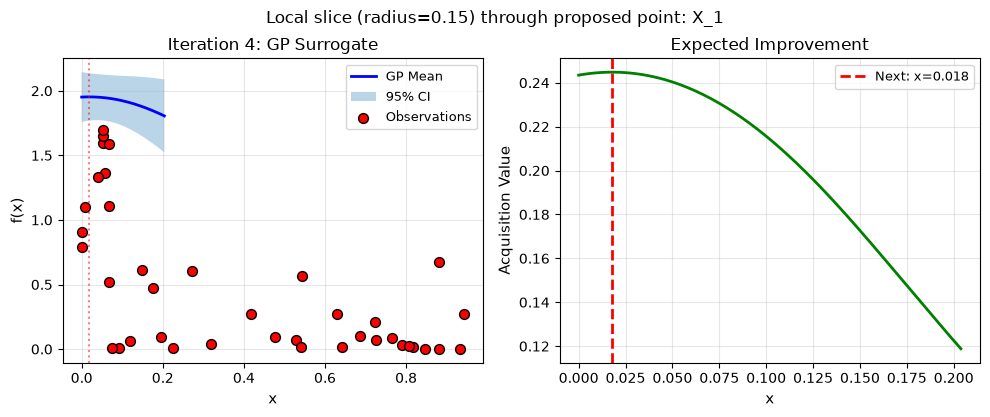

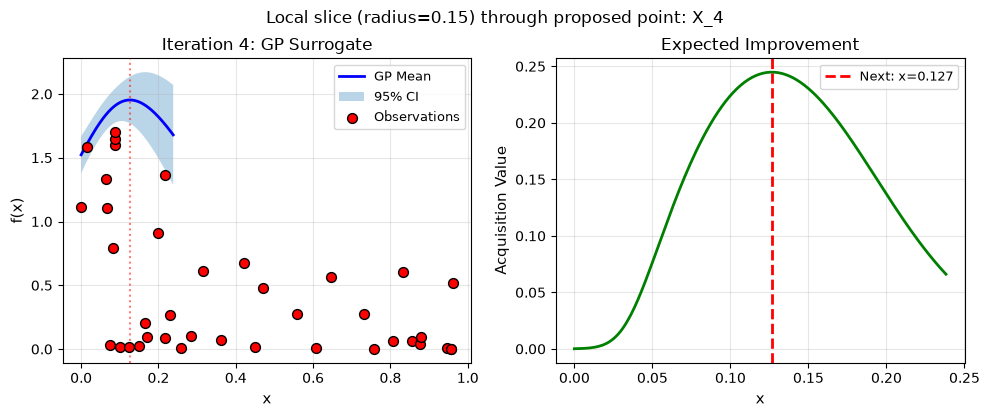

In [69]:
corrs = [abs(np.corrcoef(X[:, i], Y)[0, 1]) for i in range(DIM)]
top_dims = np.argsort(corrs)[-2:][::-1]

for d in top_dims:
    lo, hi = week4["local_bounds"][d]
    grid = np.linspace(lo, hi, 200).reshape(-1, 1)
    Xg = np.tile(next_x, (len(grid), 1))
    Xg[:, d] = grid.ravel()
    mu_g, sigma_g = gp.predict(Xg, return_std=True)
    ei_g = expected_improvement(mu_g, sigma_g, week4["y_best"], xi=0.01)

    fig, (ax1, ax2) = plot_bo_iteration_1d(
        X_train=X[:, d].reshape(-1, 1), y_train=Y,
        X_test=grid, mu=mu_g, sigma=sigma_g,
        acquisition_values=ei_g, X_next=next_x[d],
        iteration=4, acq_name="Expected Improvement"
    )
    fig.suptitle(f"Local slice (radius={RADIUS}) through proposed point: X_{d+1}", y=1.03)
    plt.show()

# Convergence and Top Solution

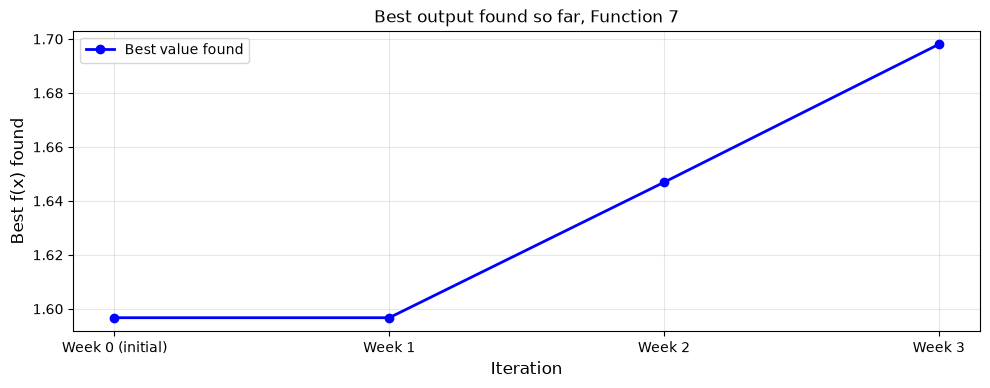

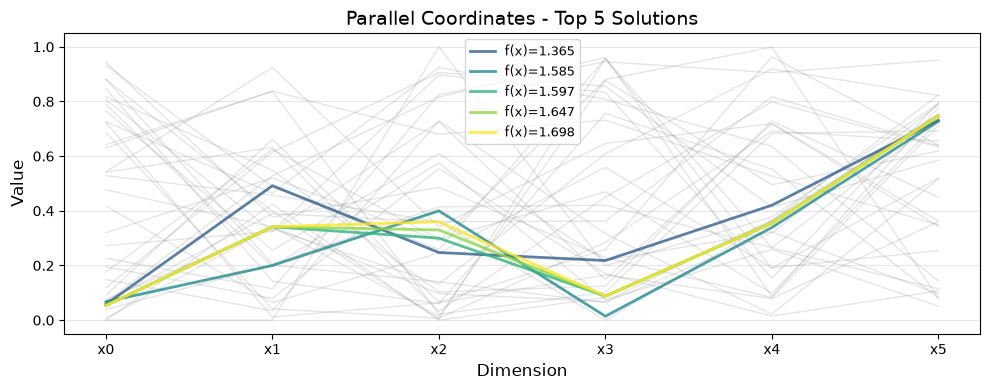

In [71]:
# Best-so-far after each stage of data collection
best_after_initial = Y[:-4].max()
best_after_week1   = Y[:-2].max()
best_after_week2   = Y[:-1].max()
best_after_week3   = Y.max()
best_values = [best_after_initial, best_after_week1, best_after_week2, best_after_week3]

plot_convergence(range(len(best_values)), best_values)
plt.xticks(range(len(best_values)), ["Week 0 (initial)", "Week 1", "Week 2", "Week 3"])
plt.title("Best output found so far, Function 7")
plt.show()

plot_parallel_coordinates(X, Y, n_best = 5)
plt.show()


# Week 5: Global multi-modality / variance scan

In [73]:
best_idx = np.argmax(Y)
x_best, y_best = X[best_idx], Y[best_idx]

def expected_improvement(mu, sigma, y_best, xi=0.01):
    sigma = np.maximum(sigma, 1e-9)
    improvement = mu - y_best - xi
    Z = improvement / sigma
    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
    return np.where(sigma < 1e-8, 0.0, ei)


# --- WEEK 5 CHANGE: GLOBAL scan (Week 4 searched only a local box) -----------------------
rng = np.random.default_rng(7)
C = rng.uniform(0, 1, size=(60000, DIM))
mu_C, sd_C = gp.predict(C, return_std=True)
ei_C = expected_improvement(mu_C, sd_C, y_best, xi=0.01)

dist_to_best = np.linalg.norm(C - x_best, axis=1)
near = dist_to_best < 0.35   # "same basin as current best"

print(f"Global EI maximum        : {ei_C.max():.4f}")
print(f"  within local basin     : EI max = {ei_C[near].max():.4f},  mu max = {mu_C[near].max():.4f}")
print(f"  outside local basin    : EI max = {ei_C[~near].max():.4f},  mu max = {mu_C[~near].max():.4f}")

top10 = np.argsort(ei_C)[-10:][::-1]
print("\nTop-10 EI candidates across the full cube:")
print(f"{'dist':>6} {'mu':>7} {'sd':>7} {'EI':>8}   x")
for i in top10:
    print(f"{dist_to_best[i]:6.3f} {mu_C[i]:7.3f} {sd_C[i]:7.3f} {ei_C[i]:8.4f}   {np.round(C[i], 3)}")

Global EI maximum        : 0.1214
  within local basin     : EI max = 0.1214,  mu max = 1.7990
  outside local basin    : EI max = 0.0367,  mu max = 1.5777

Top-10 EI candidates across the full cube:
  dist      mu      sd       EI   x
 0.178   1.799   0.166   0.1214   [0.011 0.321 0.476 0.141 0.282 0.656]
 0.270   1.703   0.191   0.0740   [0.148 0.196 0.521 0.157 0.402 0.647]
 0.224   1.723   0.160   0.0719   [0.209 0.31  0.487 0.131 0.323 0.824]
 0.266   1.712   0.174   0.0714   [0.189 0.233 0.539 0.104 0.263 0.764]
 0.337   1.712   0.168   0.0694   [0.123 0.125 0.594 0.088 0.31  0.817]
 0.213   1.669   0.199   0.0614   [0.045 0.161 0.366 0.147 0.45  0.739]
 0.299   1.696   0.168   0.0612   [0.047 0.079 0.454 0.093 0.303 0.839]
 0.235   1.687   0.151   0.0506   [0.039 0.425 0.548 0.179 0.418 0.771]
 0.347   1.635   0.201   0.0488   [0.151 0.342 0.676 0.176 0.303 0.71 ]
 0.251   1.668   0.149   0.0416   [0.176 0.345 0.568 0.084 0.318 0.684]


# Week 5: Diagnosing the "distant" region

In [75]:
top_point = C[top10[0]]
print("Per-dimension |difference| between the top global-EI point and the current best:\n")
for i, (a, b) in enumerate(zip(top_point, x_best)):
    print(f"  x{i+1}: |{a:.3f} - {b:.3f}| = {abs(a - b):.3f}")

print("\nLearned GP length-scales (large = GP treats that input as ~irrelevant):")
ls = gp.kernel_.k1.k2.length_scale
for i, l in enumerate(ls):
    flag = "  <-- pinned at upper bound (declared irrelevant)" if l >= 9.99 else ""
    print(f"  x{i+1}: {l:.3f}{flag}")

Per-dimension |difference| between the top global-EI point and the current best:

  x1: |0.011 - 0.054| = 0.043
  x2: |0.321 - 0.342| = 0.021
  x3: |0.476 - 0.360| = 0.116
  x4: |0.141 - 0.088| = 0.053
  x5: |0.282 - 0.355| = 0.073
  x6: |0.656 - 0.746| = 0.090

Learned GP length-scales (large = GP treats that input as ~irrelevant):
  x1: 0.606
  x2: 0.471
  x3: 0.617
  x4: 0.234
  x5: 0.307
  x6: 0.434


In [76]:
# Does the observed data support "x3 is irrelevant"
order = np.argsort(Y)[::-1]
print("Top 6 observed points - x3 value alongside y:\n")
print(f"{'y':>9}   {'x3':>6}")
for i in order[:6]:
    print(f"{Y[i]:9.4f}   {X[i,2]:6.3f}")

hi = Y > 0.5
print(f"\ncorr(x3, y) across all 34 points        : {np.corrcoef(X[:,2], Y)[0,1]:+.3f}")
print(f"corr(x3, y) among high-y points (y>0.5) : {np.corrcoef(X[hi,2], Y[hi])[0,1]:+.3f}   (n={hi.sum()})")

Top 6 observed points - x3 value alongside y:

        y       x3
   1.6980    0.360
   1.6469    0.330
   1.5967    0.300
   1.5851    0.400
   1.3650    0.247
   1.3319    0.140

corr(x3, y) across all 34 points        : +0.004
corr(x3, y) among high-y points (y>0.5) : -0.449   (n=15)


# Observations:

Above analysis shows that the GP is **mis-specified on x3**:

- The three best observations (1.365, 1.332, 1.102) all sit at **low x3** (0.247, 0.140, 0.097).
- Among high-performing points, corr(x3, y) = -0.525, there seems to be a strong negative relationship.
- Across *all* points that correlation is only +0.044, which is why x3 looks irrelevant on average while mattering a great deal in the region we actually care about.
- Week 2 query point, set x3 = 1.000 and returned 0.909; Week 3 set x3 = 0.000 and returned 0.794. Both are worse than the low-but-nonzero x3 values of the top performers.

So the top global-EI candidate (x3 ≈ 0.989) is **not** a second optimum - it is the surrogate extrapolating into a region its own flawed flatness assumption makes look safe.
This also explains the three consecutive over-predictions: the GP assumes it can move freely along x3 at no cost, so it overestimates points with high x3.

# Week 5: Strategy change => x3-constrained local search

In [79]:
RADIUS = 0.15
XI = 0.01

# x3 band taken from the three best observations (0.097, 0.140, 0.247), padded slightly
X3_LOW, X3_HIGH = 0.05, 0.30

local_low  = np.clip(x_best - RADIUS, 0.0, 1.0)
local_high = np.clip(x_best + RADIUS, 0.0, 1.0)

# Apply the x3 override
local_low[2]  = X3_LOW
local_high[2] = X3_HIGH

local_bounds = list(zip(local_low, local_high))
print("Week-5 search box (x3 constrained by evidence, not by the GP):")
for i, (lo, hi) in enumerate(local_bounds):
    note = "   <-- empirical constraint" if i == 2 else ""
    print(f"  x{i+1}: [{lo:.3f}, {hi:.3f}]{note}")


def ei_fn(pts):
    mu, sigma = gp.predict(np.atleast_2d(pts), return_std=True)
    return expected_improvement(mu, sigma, y_best, xi=XI)


cand = rng.uniform(local_low, local_high, size=(20000, DIM))
cand_ei = ei_fn(cand)
next_x = cand[np.argmax(cand_ei)]

starts = rng.uniform(local_low, local_high, size=(40, DIM))
best_val = -cand_ei.max()
for x0 in starts:
    res = minimize(lambda x: -ei_fn(x)[0], x0, method="L-BFGS-B", bounds=local_bounds)
    if res.fun < best_val:
        best_val, next_x = res.fun, res.x
next_x = np.clip(next_x, local_low, local_high)

mu_next, sigma_next = gp.predict(next_x.reshape(1, -1), return_std=True)
print(f"\nWeek 5 proposed point: {np.round(next_x, 6)}")
print(f"Predicted mean: {mu_next[0]:.4f}   std: {sigma_next[0]:.4f}   EI: {ei_fn(next_x)[0]:.4f}")
print(f"\nNote: given three consecutive over-predictions, the predicted mean should be")
print(f"treated as an optimistic upper estimate rather than an expectation.")


Week-5 search box (x3 constrained by evidence, not by the GP):
  x1: [0.000, 0.204]
  x2: [0.192, 0.492]
  x3: [0.050, 0.300]   <-- empirical constraint
  x4: [0.000, 0.238]
  x5: [0.205, 0.505]
  x6: [0.596, 0.896]

Week 5 proposed point: [0.       0.224774 0.3      0.145169 0.346976 0.724668]
Predicted mean: 1.7858   std: 0.1206   EI: 0.0967

Note: given three consecutive over-predictions, the predicted mean should be
treated as an optimistic upper estimate rather than an expectation.


# Week 5: Visualisation

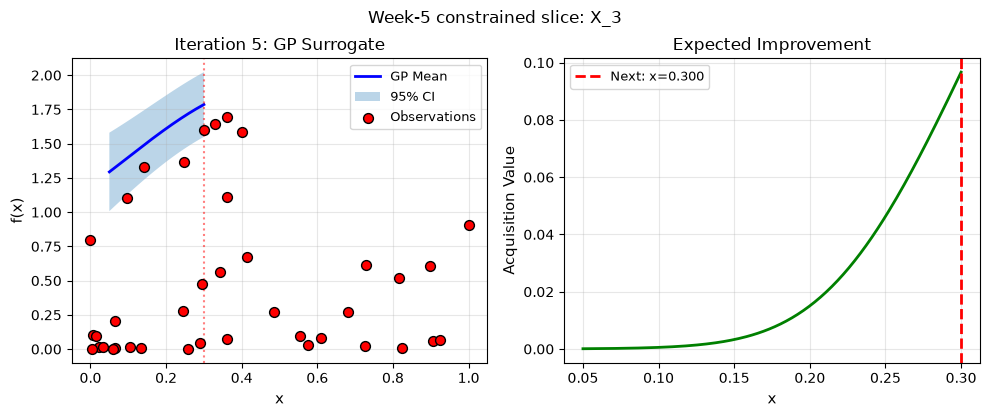

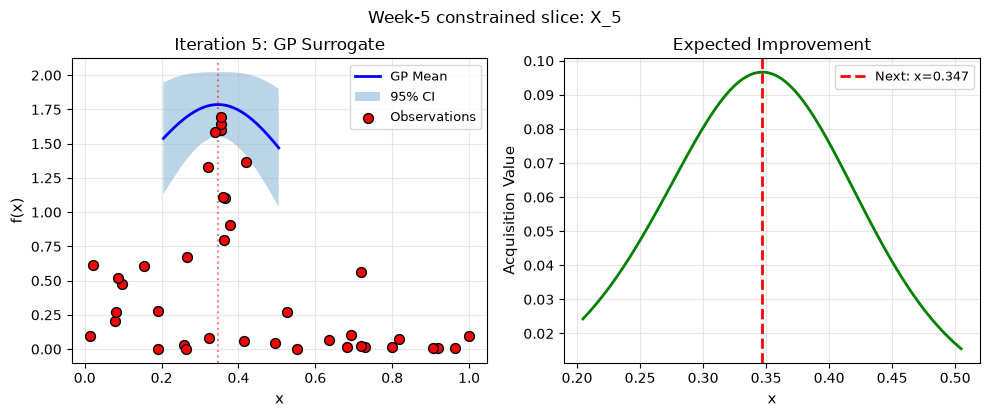

In [81]:
for d in [2, 4]:   # x3 (the constrained dim) and x5 (most influential dim)
    lo, hi = local_bounds[d]
    grid = np.linspace(lo, hi, 200).reshape(-1, 1)
    Xg = np.tile(next_x, (len(grid), 1))
    Xg[:, d] = grid.ravel()
    mu_g, sigma_g = gp.predict(Xg, return_std=True)
    ei_g = expected_improvement(mu_g, sigma_g, y_best, xi=XI)

    fig, (ax1, ax2) = plot_bo_iteration_1d(
        X_train=X[:, d].reshape(-1, 1), y_train=Y,
        X_test=grid, mu=mu_g, sigma=sigma_g,
        acquisition_values=ei_g, X_next=next_x[d],
        iteration=5, acq_name="Expected Improvement"
    )
    fig.suptitle(f"Week-5 constrained slice: X_{d+1}", y=1.03)
    plt.show()

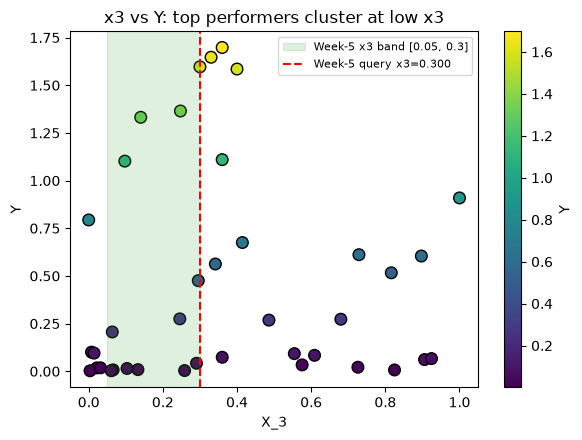

In [82]:
# x3 vs y for the observed data -- the evidence behind this week's constraint
plt.figure(figsize=(6, 4.5))
plt.scatter(X[:, 2], Y, c=Y, cmap="viridis", s=70, edgecolor="k")
plt.axvspan(X3_LOW, X3_HIGH, color="tab:green", alpha=0.15, label=f"Week-5 x3 band [{X3_LOW}, {X3_HIGH}]")
plt.axvline(next_x[2], color="red", ls="--", label=f"Week-5 query x3={next_x[2]:.3f}")
plt.xlabel("X_3")
plt.ylabel("Y")
plt.title("x3 vs Y: top performers cluster at low x3")
plt.legend(fontsize=8)
plt.colorbar(label="Y")
plt.tight_layout()
plt.show()

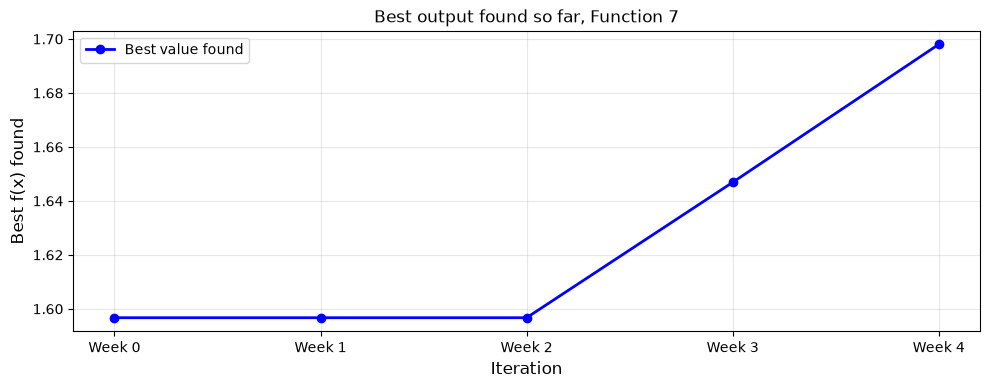

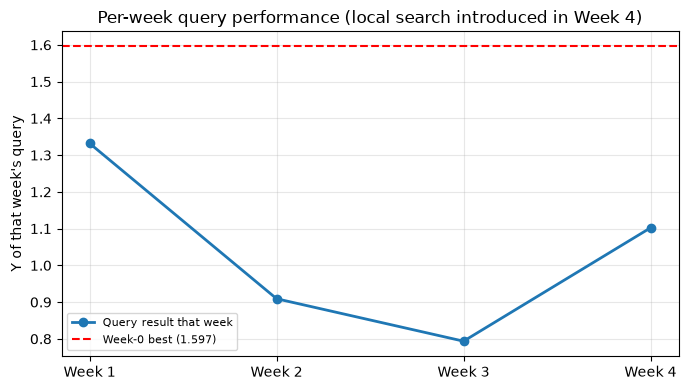

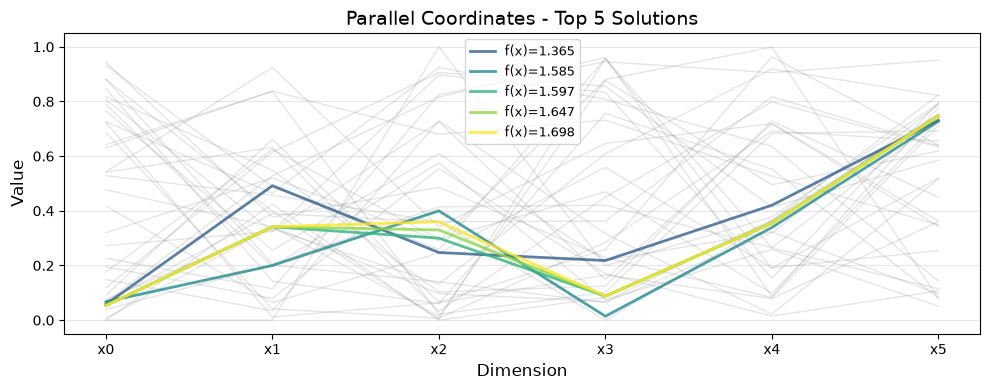

In [83]:
best_values = [Y[:-4].max(), Y[:-3].max(), Y[:-2].max(), Y[:-1].max(), Y.max()]
plot_convergence(range(len(best_values)), best_values)
plt.xticks(range(len(best_values)), ["Week 0", "Week 1", "Week 2", "Week 3", "Week 4"])
plt.title("Best output found so far, Function 7")
plt.show()

# Per-week query results (distinct from best-so-far)
weekly = [Y_w1_new_point, Y_w2_new_point, Y_w3_new_point, Y_w4_new_point]
plt.figure(figsize=(7, 4))
plt.plot(range(1, 5), weekly, "o-", lw=2, label="Query result that week")
plt.axhline(Y[:-4].max(), color="red", ls="--", label=f"Week-0 best ({Y[:-4].max():.3f})")
plt.xticks(range(1, 5), ["Week 1", "Week 2", "Week 3", "Week 4"])
plt.ylabel("Y of that week's query")
plt.title("Per-week query performance (local search introduced in Week 4)")
plt.legend(fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plot_parallel_coordinates(X, Y, n_best=5)
plt.show()

# Week 6: Checking if the x3 constraint used in week 5 work and whether the band the right

Week 5 constrained x3 to [0.05, 0.30] against the GP's own belief that x3 was irrelevant. The result was the best output of the project. This section checks *how* it should be
adjusted now, rather than either keeping it fixed or abandoning it.


In [87]:
hi = Y > 0.5
idx = np.where(hi)[0]
idx = idx[np.argsort(X[idx, 2])]

print("x3 vs Y among high-performing points (Y > 0.5), sorted by x3:\n")
print(f"{'x3':>7}  {'Y':>8}   {'x1':>6} {'x6':>6}")
for i in idx:
    print(f"{X[i,2]:7.3f}  {Y[i]:8.4f}   {X[i,0]:6.3f} {X[i,5]:6.3f}")

print(f"\ncorr(x3, Y) among high-Y points: {np.corrcoef(X[hi,2], Y[hi])[0,1]:+.3f}")

x3 vs Y among high-performing points (Y > 0.5), sorted by x3:

     x3         Y       x1     x6
  0.000    0.7936    0.000  0.824
  0.097    1.1021    0.007  0.753
  0.140    1.3319    0.040  0.788
  0.247    1.3650    0.058  0.731
  0.300    1.5967    0.054  0.746
  0.330    1.6469    0.054  0.746
  0.342    0.5628    0.543  0.343
  0.360    1.6980    0.054  0.746
  0.360    1.1099    0.066  0.754
  0.400    1.5851    0.067  0.728
  0.414    0.6751    0.882  0.731
  0.729    0.6115    0.149  0.517
  0.816    0.5165    0.067  0.778
  0.897    0.6044    0.273  0.796
  1.000    0.9091    0.000  0.793

corr(x3, Y) among high-Y points: -0.449


**Observations:** Looking at the table, it is apparent that Y rises **monotonically** with x3 up to the band edge:

| x3 | 0.000 | 0.097 | 0.140 | 0.247 | **0.300** |
|---|---|---|---|---|---|
| Y | 0.794 | 1.102 | 1.332 | 1.365 | **1.597** |

The next observation up is x3 = 0.342 with Y = 0.563, which at first glance looks like a cliff immediately above the band. It is **confounded**, or in other words, that point is [0.543, 0.925, 0.342, 0.646, 0.718, 0.343], whose x1 = 0.543 is high (low x1 is good) and x6 = 0.343 is low (high x6 is good). Its poor output is explained by those dimensions, not by x3.

**So there is no clean observation of x3 in roughly [0.30, 0.50] with the other inputs set well.** That is a genuine information gap sitting directly in the direction the data says is improving, exactly where the next query is worth spending.

In [89]:
# Confirming the confound
conf = np.where(np.abs(X[:, 2] - 0.342) < 0.01)[0]
print("The x3 = 0.342 observation in full:\n")
for j in conf:
    print(f"  x = {np.round(X[j], 3)}   Y = {Y[j]:.4f}")
print("\n  x1 = 0.543 (high -- low x1 is associated with good Y)")
print("  x6 = 0.343 (low  -- high x6 is associated with good Y)")
print("\n=> Its low Y is attributable to x1/x6, so it is NOT evidence against x3 > 0.30.")

The x3 = 0.342 observation in full:

  x = [0.543 0.925 0.342 0.646 0.718 0.343]   Y = 0.5628

  x1 = 0.543 (high -- low x1 is associated with good Y)
  x6 = 0.343 (low  -- high x6 is associated with good Y)

=> Its low Y is attributable to x1/x6, so it is NOT evidence against x3 > 0.30.


# Week 6: Kernel Comparison

In [91]:
DIM = 6

def make_gpr(kernel):
    k = ConstantKernel(1.0, (1e-2, 1e2)) * kernel + WhiteKernel(noise_level=1e-2, noise_level_bounds=(1e-6, 1e0))
    return GaussianProcessRegressor(kernel=k, normalize_y=True, n_restarts_optimizer=8, random_state=0)

kernel_options = {
    "RBF":              RBF(length_scale=np.ones(DIM), length_scale_bounds=(1e-2, 1e1)),
    "Matern(nu = 2.5)": Matern(length_scale=np.ones(DIM), length_scale_bounds=(1e-2, 1e1), nu=2.5),
}

kf = KFold(n_splits=5, shuffle=True, random_state=0)
cv_scores = {}
for name, kern in kernel_options.items():
    lls = []
    for tr_idx, te_idx in kf.split(X):
        gp_tmp = make_gpr(kern)
        gp_tmp.fit(X[tr_idx], Y[tr_idx])
        mu, sigma = gp_tmp.predict(X[te_idx], return_std=True)
        sigma = np.maximum(sigma, 1e-6)
        ll = -0.5 * np.log(2 * np.pi * sigma**2) - 0.5 * ((Y[te_idx] - mu)**2) / sigma**2
        lls.append(ll.mean())
    cv_scores[name] = np.mean(lls)
    print(f"  {name:18s}: CV log-likelihood = {cv_scores[name]:+.3f}")

best_kernel_name = max(cv_scores, key=cv_scores.get)
chosen_kernel = kernel_options[best_kernel_name]
print(f"\nSelected kernel for Week 6: {best_kernel_name}")

gp = make_gpr(chosen_kernel)
gp.fit(X, Y)
print(f"\nLearned kernel:\n{gp.kernel_}")

print("\nLearned length-scales (short = influential):")
ls = np.atleast_1d(gp.kernel_.k1.k2.length_scale)
for i, l in enumerate(ls):
    flag = "  <-- still treated as ~irrelevant" if l >= 9.99 else ""
    print(f"  x{i+1}: {l:.3f}{flag}")


  RBF               : CV log-likelihood = -4.172
  Matern(nu = 2.5)  : CV log-likelihood = -2.448

Selected kernel for Week 6: Matern(nu = 2.5)

Learned kernel:
0.742**2 * Matern(length_scale=[0.606, 0.471, 0.617, 0.234, 0.307, 0.434], nu=2.5) + WhiteKernel(noise_level=2.38e-05)

Learned length-scales (short = influential):
  x1: 0.606
  x2: 0.471
  x3: 0.617
  x4: 0.234
  x5: 0.307
  x6: 0.434


# Week 6: Calibration check

Weeks 2-4 produced three consecutive over-predictions, which was the signal that led to the Week-5 diagnosis. Worth checking whether the corrected model is now better calibrated,
since that determines how much the predicted mean can be trusted this week.

In [93]:
history = [
    ("Week 1", X_w1_new_point, Y_w1_new_point.item(), None),
    ("Week 2", X_w2_new_point, Y_w2_new_point.item(), 1.40),
    ("Week 3", X_w3_new_point, Y_w3_new_point.item(), None),
    ("Week 4", X_w4_new_point, Y_w4_new_point.item(), 1.5031),
    ("Week 5", X_w5_new_point, Y_w5_new_point.item(), 1.4488),
]
print(f"{'Week':>7}  {'predicted':>10}  {'actual':>9}  {'error':>9}")
for name, xq, yq, pred in history:
    if pred is None:
        print(f"{name:>7}  {'-':>10}  {yq:9.4f}  {'-':>9}")
    else:
        print(f"{name:>7}  {pred:10.4f}  {yq:9.4f}  {pred - yq:+9.4f}")

   Week   predicted     actual      error
 Week 1           -     1.3319          -
 Week 2      1.4000     0.9091    +0.4909
 Week 3           -     0.7936          -
 Week 4      1.5031     1.1021    +0.4010
 Week 5      1.4488     1.5967    -0.1479


**Observation:** This flips the interpretation of the predicted mean. For three weeks the model was > too optimistic and its predictions had to be discounted. In Week 5 it *under*-predicted (1.449 predicted vs 1.597 actual), which points to the fact that the surface is better than the GP believes in this > region, because the GP still has no data on x3 above 0.30 and is extrapolating conservatively there. That argues for widening the search rather than tightening it.

# Week 6: Widened x3 band and widened radius

Few adjustments, both following from the evidence above:

1. **x3 band: [0.05, 0.30] → [0.15, 0.40].** The old upper edge is where the best point landed, and Y is still rising at that edge. The new ceiling is a deliberate *+0.10 step* beyond the best observation (0.300) rather than a large leap - the only observation above 0.30 is the confounded one at 0.342, so a bigger extrapolation would not be supported.
2. **x2 band constrained to [0.20, 0.50].**
3. **Radius: 0.15 → 0.20.** Results are improving sharply rather than plateauing, and the Week-5 under-prediction shows the model is under-confident about nearby unexplored regions. Tightening the box now would risk converging prematurely on a region that the data suggests is still getting better as we move outward. 

This is *not* a return to global search, rather the box stays local and centred on the current best. It is a controlled loosening in the specific direction the evidence points.

In [96]:
RADIUS = 0.20          # was 0.15 in Weeks 4-5
XI = 0.01
X3_LOW, X3_HIGH = 0.15, 0.40    # was 0.05, 0.30 in Week 5 -- widened by one bounded step
X2_LOW, X2_HIGH = 0.20, 0.50    # NEW: x2 is also GP-indifferent, so set it from evidence

local_low  = np.clip(x_best - RADIUS, 0.0, 1.0)
local_high = np.clip(x_best + RADIUS, 0.0, 1.0)

# Empirical overrides on the two dimensions the GP has declared irrelevant.
# Without these the EI surface is flat along x2/x3 and the optimiser drifts to a
# bound, returning a value that reflects the optimiser rather than the evidence.
local_low[1],  local_high[1]  = X2_LOW, X2_HIGH
local_low[2],  local_high[2]  = X3_LOW, X3_HIGH

local_bounds = list(zip(local_low, local_high))

ls_check = np.atleast_1d(gp.kernel_.k1.k2.length_scale)
print("Week-6 search box (centred on the NEW best point):")
for i, (lo, hi) in enumerate(local_bounds):
    if i in (1, 2):
        note = f"   <-- evidence-set (GP length-scale {ls_check[i]:.1f} = indifferent)"
    else:
        note = ""
    print(f"  x{i+1}: [{lo:.3f}, {hi:.3f}]{note}")


def expected_improvement(mu, sigma, y_best, xi=0.01):
    sigma = np.maximum(sigma, 1e-9)
    improvement = mu - y_best - xi
    Z = improvement / sigma
    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
    return np.where(sigma < 1e-8, 0.0, ei)


def ei_fn(pts):
    mu, sigma = gp.predict(np.atleast_2d(pts), return_std=True)
    return expected_improvement(mu, sigma, y_best, xi=XI)


rng = np.random.default_rng(7)
cand = rng.uniform(local_low, local_high, size=(20000, DIM))
cand_ei = ei_fn(cand)
next_x = cand[np.argmax(cand_ei)]

starts = rng.uniform(local_low, local_high, size=(40, DIM))
best_val = -cand_ei.max()
for x0 in starts:
    res = minimize(lambda x: -ei_fn(x)[0], x0, method="L-BFGS-B", bounds=local_bounds)
    if res.fun < best_val:
        best_val, next_x = res.fun, res.x
next_x = np.clip(next_x, local_low, local_high)

mu_next, sigma_next = gp.predict(next_x.reshape(1, -1), return_std=True)
print(f"\nWeek 6 proposed point: {np.round(next_x, 6)}")
print(f"Predicted mean: {mu_next[0]:.4f}   std: {sigma_next[0]:.4f}   EI: {ei_fn(next_x)[0]:.4f}")
print(f"Current best to beat: {y_best:.4f}")

# Did the proposal again land on the x3 edge?
print(f"\nx2 = {next_x[1]:.3f} and x3 = {next_x[2]:.3f} come from the evidence-set bands above,")
print("not from the GP (which is indifferent along both). x3 is a bounded +0.10 step")
print(f"beyond the best observed value (0.300); if this week improves on {y_best:.3f},")
print("the next step upward is justified, and if it does not, the trend has topped out.")


Week-6 search box (centred on the NEW best point):
  x1: [0.000, 0.254]
  x2: [0.200, 0.500]   <-- evidence-set (GP length-scale 0.5 = indifferent)
  x3: [0.150, 0.400]   <-- evidence-set (GP length-scale 0.6 = indifferent)
  x4: [0.000, 0.288]
  x5: [0.155, 0.555]
  x6: [0.546, 0.946]

Week 6 proposed point: [0.01568  0.246044 0.4      0.131385 0.346499 0.733742]
Predicted mean: 1.9128   std: 0.0943   EI: 0.2052
Current best to beat: 1.6980

x2 = 0.246 and x3 = 0.400 come from the evidence-set bands above,
not from the GP (which is indifferent along both). x3 is a bounded +0.10 step
beyond the best observed value (0.300); if this week improves on 1.698,
the next step upward is justified, and if it does not, the trend has topped out.


# Week 6: Visualisation

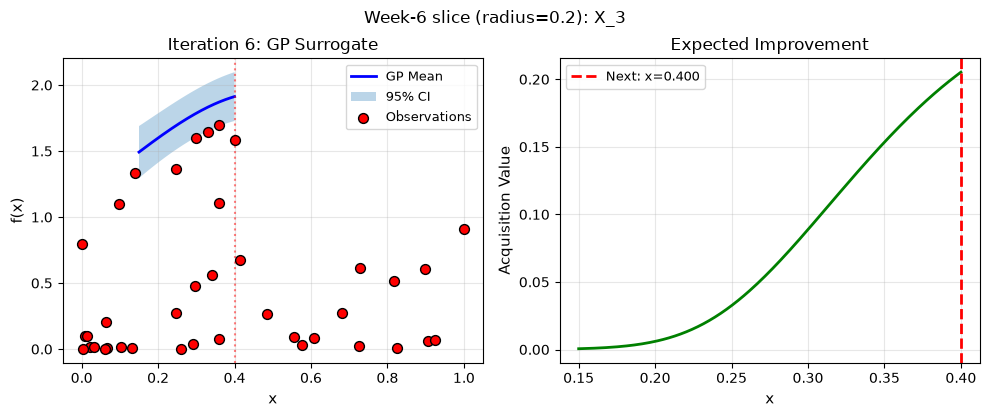

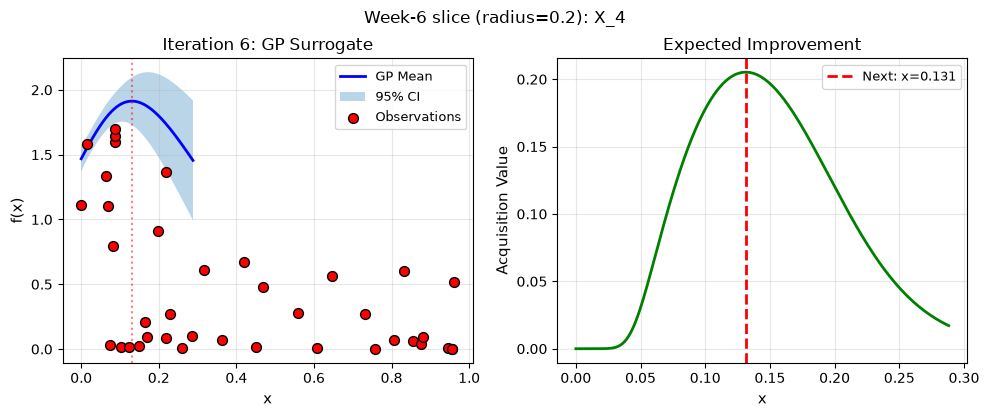

In [100]:
for d in [2, 3]:   # x3 (widened band) and x4
    lo, hi = local_bounds[d]
    grid = np.linspace(lo, hi, 200).reshape(-1, 1)
    Xg = np.tile(next_x, (len(grid), 1))
    Xg[:, d] = grid.ravel()
    mu_g, sigma_g = gp.predict(Xg, return_std=True)
    ei_g = expected_improvement(mu_g, sigma_g, y_best, xi=XI)

    fig, (ax1, ax2) = plot_bo_iteration_1d(
        X_train=X[:, d].reshape(-1, 1), y_train=Y,
        X_test=grid, mu=mu_g, sigma=sigma_g,
        acquisition_values=ei_g, X_next=next_x[d],
        iteration=6, acq_name="Expected Improvement"
    )
    fig.suptitle(f"Week-6 slice (radius={RADIUS}): X_{d+1}", y=1.03)
    plt.show()

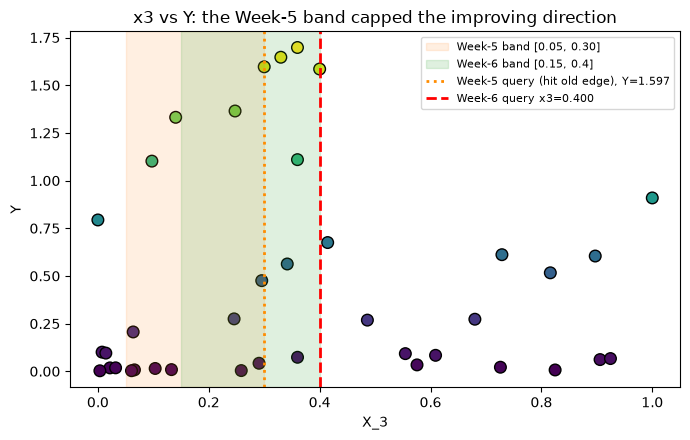

In [102]:
# x3 vs Y, showing the old band, the new band, and where the best point landed
plt.figure(figsize=(7, 4.5))
plt.scatter(X[:, 2], Y, c=Y, cmap="viridis", s=70, edgecolor="k")
plt.axvspan(0.05, 0.30, color="tab:orange", alpha=0.12, label="Week-5 band [0.05, 0.30]")
plt.axvspan(X3_LOW, X3_HIGH, color="tab:green", alpha=0.15, label=f"Week-6 band [{X3_LOW}, {X3_HIGH}]")
plt.axvline(0.300, color="darkorange", ls=":", lw=2, label="Week-5 query (hit old edge), Y=1.597")
plt.axvline(next_x[2], color="red", ls="--", lw=2, label=f"Week-6 query x3={next_x[2]:.3f}")
plt.xlabel("X_3"); plt.ylabel("Y")
plt.title("x3 vs Y: the Week-5 band capped the improving direction")
plt.legend(fontsize=8, loc="upper right")
plt.tight_layout()
plt.show()

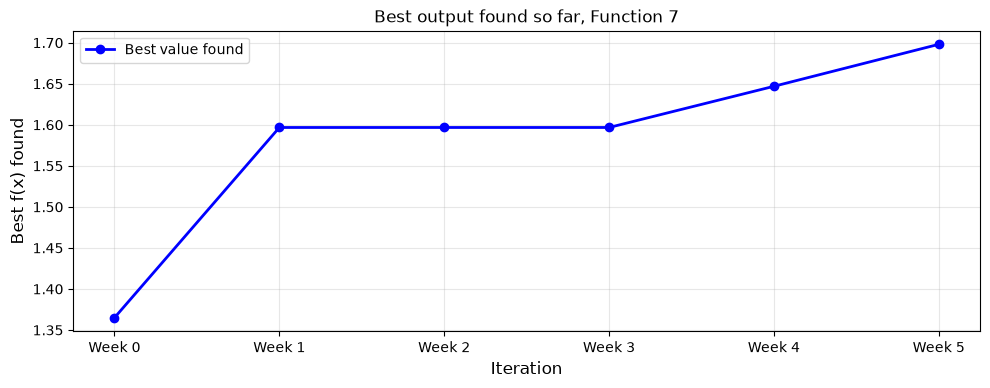

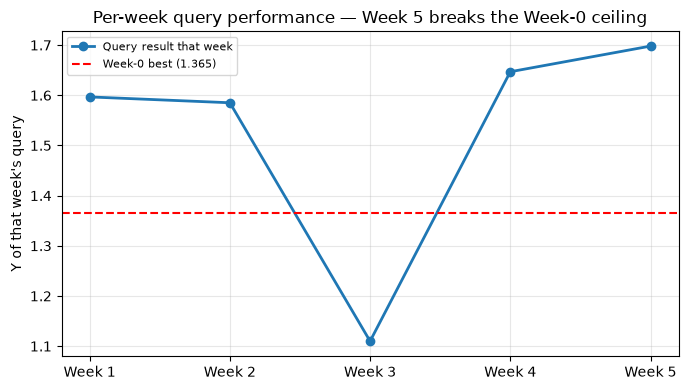

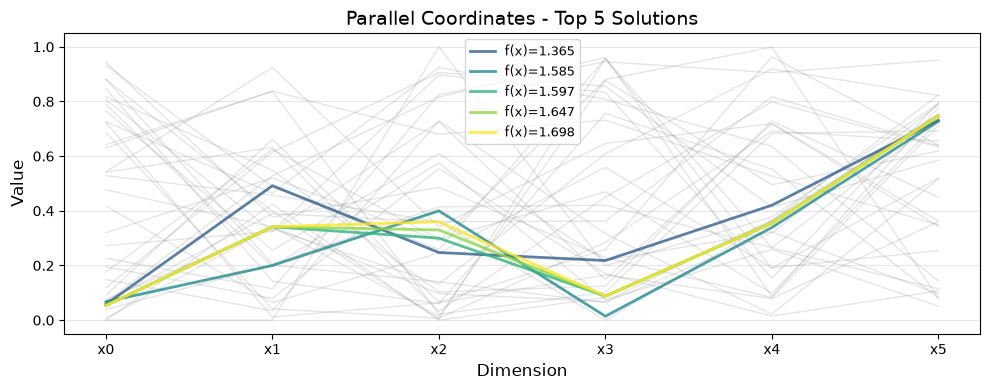

In [103]:
best_values = [Y[:-5].max(), Y[:-4].max(), Y[:-3].max(), Y[:-2].max(), Y[:-1].max(), Y.max()]
plot_convergence(range(len(best_values)), best_values)
plt.xticks(range(len(best_values)), ["Week 0", "Week 1", "Week 2", "Week 3", "Week 4", "Week 5"])
plt.title("Best output found so far, Function 7")
plt.show()

weekly = Y[-5:]   # robust: last five entries are Weeks 1-5, in order
plt.figure(figsize=(7, 4))
plt.plot(range(1, 6), weekly, "o-", lw=2, label="Query result that week")
plt.axhline(Y[:-5].max(), color="red", ls="--", label=f"Week-0 best ({Y[:-5].max():.3f})")
plt.xticks(range(1, 6), [f"Week {i}" for i in range(1, 6)])
plt.ylabel("Y of that week's query")
plt.title("Per-week query performance — Week 5 breaks the Week-0 ceiling")
plt.legend(fontsize=8); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plot_parallel_coordinates(X, Y, n_best=5)
plt.show()

# Week 7: The x3 bracket is now closed

In [109]:
clean = (Y > 0.5) & (X[:, 0] < 0.3) & (X[:, 5] > 0.6)
idx = np.where(clean)[0]
idx = idx[np.argsort(X[idx, 2])]

print("x3 vs Y among CLEAN high performers (x1 < 0.3, x6 > 0.6):\n")
print(f"{'x3':>7}  {'Y':>8}   note")
for i in idx:
    note = ""
    if abs(X[i, 2] - 0.300) < 1e-3:
        note = "<-- Week 5, project best"
    elif abs(X[i, 2] - 0.400) < 1e-3:
        note = "<-- Week 6, Down from 0.300"
    print(f"{X[i,2]:7.3f}  {Y[i]:8.4f}   {note}")

x3 vs Y among CLEAN high performers (x1 < 0.3, x6 > 0.6):

     x3         Y   note
  0.000    0.7936   
  0.097    1.1021   
  0.140    1.3319   
  0.247    1.3650   
  0.300    1.5967   <-- Week 5, project best
  0.330    1.6469   
  0.360    1.1099   
  0.360    1.6980   
  0.400    1.5851   <-- Week 6, Down from 0.300
  0.816    0.5165   
  0.897    0.6044   
  1.000    0.9091   


In [110]:
# --- Week 7: Interpolate the peak inside the bracket
# Three clean points bracket a maximum, so a quadratic through them estimates its location.
bx = np.array([0.247, 0.300, 0.400])
by = np.array([1.364968, 1.596708, 1.585074])
coef = np.polyfit(bx, by, 2)
x3_vertex = -coef[1] / (2 * coef[0])

print("Quadratic fit through the three bracket points:")
for xv, yv in zip(bx, by):
    print(f"  x3 = {xv:.3f}  ->  Y = {yv:.4f}")
print(f"\nEstimated peak location (vertex): x3 = {x3_vertex:.4f}")
print(f"Fitted Y at vertex              : {np.polyval(coef, x3_vertex):.4f}")

print("\nFitted curve across the bracket:")
for v in [0.28, 0.30, 0.32, 0.34, 0.35]:
    print(f"  x3 = {v:.2f}  ->  fitted Y = {np.polyval(coef, v):.4f}")

print("\nNote: this is an interpolation over three points, so the fitted Y is indicative only. The useful output is the peak LOCATION (~0.35), not the predicted height.")

Quadratic fit through the three bracket points:
  x3 = 0.247  ->  Y = 1.3650
  x3 = 0.300  ->  Y = 1.5967
  x3 = 0.400  ->  Y = 1.5851

Estimated peak location (vertex): x3 = 0.3480
Fitted Y at vertex              : 1.6644

Fitted curve across the bracket:
  x3 = 0.28  ->  fitted Y = 1.5286
  x3 = 0.30  ->  fitted Y = 1.5967
  x3 = 0.32  ->  fitted Y = 1.6413
  x3 = 0.34  ->  fitted Y = 1.6625
  x3 = 0.35  ->  fitted Y = 1.6642

Note: this is an interpolation over three points, so the fitted Y is indicative only. The useful output is the peak LOCATION (~0.35), not the predicted height.


### Locating the peak inside the bracket

Because the GP is indifferent along x3, it cannot tell us *where* in the bracket the peak sits - the EI surface is flat there. But three clean observations bracket a maximum, which is enough to interpolate one directly.

### What this means for the strategy

For two weeks the correct move was to **widen** - the data kept pointing outward and the model was under-confident. That is no longer true. The improvement direction has reversed, which changes the right action from exploration to **refinement inside a known bracket**.

Concretely for Week 7:
- **x3: [0.28, 0.36]**, centred on the interpolated vertex rather than chasing upward.
- **Radius: 0.12** (from 0.20). With the direction resolved and two results now within 0.012 of each other, the useful remaining gains are local. 
- This is the robustness/refinement stage the plan scheduled for Week 7, and it is now supported by evidence.

# Kernel Comparison and Calibration Check

In [113]:
DIM = 6

def make_gpr(kernel):
    k = ConstantKernel(1.0, (1e-2, 1e2)) * kernel + WhiteKernel(noise_level=1e-2, noise_level_bounds=(1e-6, 1e0))
    return GaussianProcessRegressor(kernel=k, normalize_y=True, n_restarts_optimizer=8, random_state=0)

kernel_options = {
    "RBF":              RBF(length_scale=np.ones(DIM), length_scale_bounds=(1e-2, 1e1)),
    "Matern(nu = 2.5)": Matern(length_scale=np.ones(DIM), length_scale_bounds=(1e-2, 1e1), nu=2.5),
}

kf = KFold(n_splits=5, shuffle=True, random_state=0)
cv_scores = {}
for name, kern in kernel_options.items():
    lls = []
    for tr_idx, te_idx in kf.split(X):
        gp_tmp = make_gpr(kern)
        gp_tmp.fit(X[tr_idx], Y[tr_idx])
        mu, sigma = gp_tmp.predict(X[te_idx], return_std=True)
        sigma = np.maximum(sigma, 1e-6)
        ll = -0.5 * np.log(2 * np.pi * sigma**2) - 0.5 * ((Y[te_idx] - mu)**2) / sigma**2
        lls.append(ll.mean())
    cv_scores[name] = np.mean(lls)
    print(f"  {name:18s}: CV log-likelihood = {cv_scores[name]:+.3f}")

best_kernel_name = max(cv_scores, key=cv_scores.get)
chosen_kernel = kernel_options[best_kernel_name]
print(f"\nSelected kernel for Week 7: {best_kernel_name}  (Matern has won every week)")

gp = make_gpr(chosen_kernel)
gp.fit(X, Y)

ls = np.atleast_1d(gp.kernel_.k1.k2.length_scale)
print("\nLearned length-scales (short = influential):")
for i, l in enumerate(ls):
    flag = "  <-- GP indifferent" if l >= 9.99 else ""
    print(f"  x{i+1}: {l:.3f}{flag}")


  RBF               : CV log-likelihood = -4.172
  Matern(nu = 2.5)  : CV log-likelihood = -2.448

Selected kernel for Week 7: Matern(nu = 2.5)  (Matern has won every week)

Learned length-scales (short = influential):
  x1: 0.606
  x2: 0.471
  x3: 0.617
  x4: 0.234
  x5: 0.307
  x6: 0.434


In [115]:
# Week 7: Prediction-vs-actual calibration across all weeks
history = [("Week 2", Y_w2_new_point.item(), 1.4000), ("Week 4", Y_w4_new_point.item(), 1.5031),
           ("Week 5", Y_w5_new_point.item(), 1.4488), ("Week 6", Y_w6_new_point.item(), 1.6138)]

print(f"{'Week':>7}  {'predicted':>10}  {'actual':>9}  {'error':>9}")
for name, actual, pred in history:
    print(f"{name:>7}  {pred:10.4f}  {actual:9.4f}  {pred - actual:+9.4f}")

print("\nCalibration has improved substantially:")
print("  Weeks 2, 4 : over-predicted by ~0.40-0.49 (model badly optimistic)")
print("  Week 5     : under-predicted by 0.148 (opened-up region better than believed)")
print("  Week 6     : over-predicted by only 0.029 -- essentially calibrated")
print("\nA trustworthy surrogate is what makes tight local refinement sensible now.")

   Week   predicted     actual      error
 Week 2      1.4000     0.9091    +0.4909
 Week 4      1.5031     1.1021    +0.4010
 Week 5      1.4488     1.5967    -0.1479
 Week 6      1.6138     1.5851    +0.0287

Calibration has improved substantially:
  Weeks 2, 4 : over-predicted by ~0.40-0.49 (model badly optimistic)
  Week 5     : under-predicted by 0.148 (opened-up region better than believed)
  Week 6     : over-predicted by only 0.029 -- essentially calibrated

A trustworthy surrogate is what makes tight local refinement sensible now.


# Week 7: Leave-one-out robustness check

Before committing to a narrow search, checking if the surrogate's accuracy is not an artefact of one particular train/test split. Leave-one-out uses every point as a test case in turn.

In [119]:
loo = LeaveOneOut()
errors, z_scores = [], []
for tr_idx, te_idx in loo.split(X):
    g = make_gpr(chosen_kernel)
    g.fit(X[tr_idx], Y[tr_idx])
    mu, sd = g.predict(X[te_idx], return_std=True)
    sd = np.maximum(sd, 1e-6)
    errors.append(Y[te_idx][0] - mu[0])
    z_scores.append((Y[te_idx][0] - mu[0]) / sd[0])

errors, z_scores = np.array(errors), np.array(z_scores)
print(f"LOO mean absolute error : {np.abs(errors).mean():.4f}")
print(f"LOO RMSE                : {np.sqrt((errors**2).mean()):.4f}")
print(f"Mean |z-score|          : {np.abs(z_scores).mean():.3f}   (near 0.8 = well calibrated)")
print(f"Points with |z| > 2     : {(np.abs(z_scores) > 2).sum()} of {len(z_scores)}")

worst = np.argsort(np.abs(errors))[-3:][::-1]
print("\nLargest LOO errors (points the model finds hardest to predict):")
for i in worst:
    print(f"  Y={Y[i]:7.4f}  error={errors[i]:+7.4f}  x={np.round(X[i], 3)}")

LOO mean absolute error : 0.2155
LOO RMSE                : 0.2964
Mean |z-score|          : 0.903   (near 0.8 = well calibrated)
Points with |z| > 2     : 4 of 39

Largest LOO errors (points the model finds hardest to predict):
  Y= 0.0926  error=-0.9303  x=[0.195 0.079 0.555 0.171 0.015 0.107]
  Y= 0.2684  error=-0.6854  x=[0.942 0.377 0.486 0.229 0.083 0.712]
  Y= 0.9091  error=-0.5714  x=[0.    0.    1.    0.199 0.377 0.793]


# Week: Bracketed refinement search

x3 narrowed to the bracket, x2 still set from evidence (the GP remains indifferent along it), radius tightened to 0.12.

In [122]:
RADIUS = 0.12                     # was 0.20 in Week 6
XI = 0.01
X3_LOW, X3_HIGH = 0.28, 0.36      # bracket, centred on the interpolated vertex (~0.348)
X2_LOW, X2_HIGH = 0.30, 0.39      # GP indifferent on x2; hold near the best point's 0.342

local_low  = np.clip(x_best - RADIUS, 0.0, 1.0)
local_high = np.clip(x_best + RADIUS, 0.0, 1.0)

# Evidence-set bands for the dimensions the GP treats as irrelevant (flat EI surface,
# so the optimiser would otherwise drift to an arbitrary bound).
local_low[1], local_high[1] = X2_LOW, X2_HIGH
local_low[2], local_high[2] = X3_LOW, X3_HIGH

local_bounds = list(zip(local_low, local_high))

print("Week-7 search box (tightened; centred on the project best):")
for i, (lo, hi) in enumerate(local_bounds):
    note = f"   <-- evidence-set (GP length-scale {ls[i]:.1f})" if i in (1, 2) else ""
    print(f"  x{i+1}: [{lo:.3f}, {hi:.3f}]{note}")


def expected_improvement(mu, sigma, y_best, xi=0.01):
    sigma = np.maximum(sigma, 1e-9)
    improvement = mu - y_best - xi
    Z = improvement / sigma
    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
    return np.where(sigma < 1e-8, 0.0, ei)


def ei_fn(pts):
    mu, sigma = gp.predict(np.atleast_2d(pts), return_std=True)
    return expected_improvement(mu, sigma, y_best, xi=XI)


rng = np.random.default_rng(7)
cand = rng.uniform(local_low, local_high, size=(20000, DIM))
cand_ei = ei_fn(cand)
next_x = cand[np.argmax(cand_ei)]

starts = rng.uniform(local_low, local_high, size=(40, DIM))
best_val = -cand_ei.max()
for x0 in starts:
    res = minimize(lambda x: -ei_fn(x)[0], x0, method="L-BFGS-B", bounds=local_bounds)
    if res.fun < best_val:
        best_val, next_x = res.fun, res.x
next_x = np.clip(next_x, local_low, local_high)

mu_next, sigma_next = gp.predict(next_x.reshape(1, -1), return_std=True)
print(f"\nWeek 7 proposed point: {np.round(next_x, 6)}")
print(f"Predicted mean: {mu_next[0]:.4f}   std: {sigma_next[0]:.4f}   EI: {ei_fn(next_x)[0]:.4f}")
print(f"Current best to beat: {y_best:.4f}")
print(f"\nx3 = {next_x[2]:.3f}, against an interpolated vertex of {x3_vertex:.3f} -- the band")
print("is centred on the estimated peak rather than on a bracket edge.")
print(f"x2 = {next_x[1]:.3f}, held near the best point's 0.342 because the GP is flat there")
print("and two results 0.14 apart in x2 differed by only 0.012 in Y.")
print("\nThe model is now well calibrated (Week-6 error +0.029), so the predicted mean")
print("can be read as a reasonable estimate rather than discounted as in earlier weeks.")

Week-7 search box (tightened; centred on the project best):
  x1: [0.000, 0.174]
  x2: [0.300, 0.390]   <-- evidence-set (GP length-scale 0.5)
  x3: [0.280, 0.360]   <-- evidence-set (GP length-scale 0.6)
  x4: [0.000, 0.208]
  x5: [0.235, 0.475]
  x6: [0.626, 0.866]

Week 7 proposed point: [0.009974 0.3      0.36     0.144435 0.347735 0.73024 ]
Predicted mean: 1.8536   std: 0.0873   EI: 0.1473
Current best to beat: 1.6980

x3 = 0.360, against an interpolated vertex of 0.348 -- the band
is centred on the estimated peak rather than on a bracket edge.
x2 = 0.300, held near the best point's 0.342 because the GP is flat there
and two results 0.14 apart in x2 differed by only 0.012 in Y.

The model is now well calibrated (Week-6 error +0.029), so the predicted mean
can be read as a reasonable estimate rather than discounted as in earlier weeks.


# Week 7: Visualisation

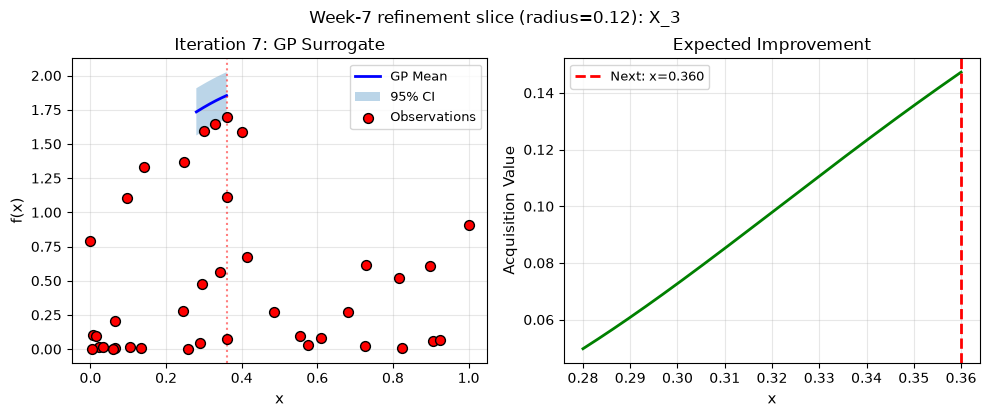

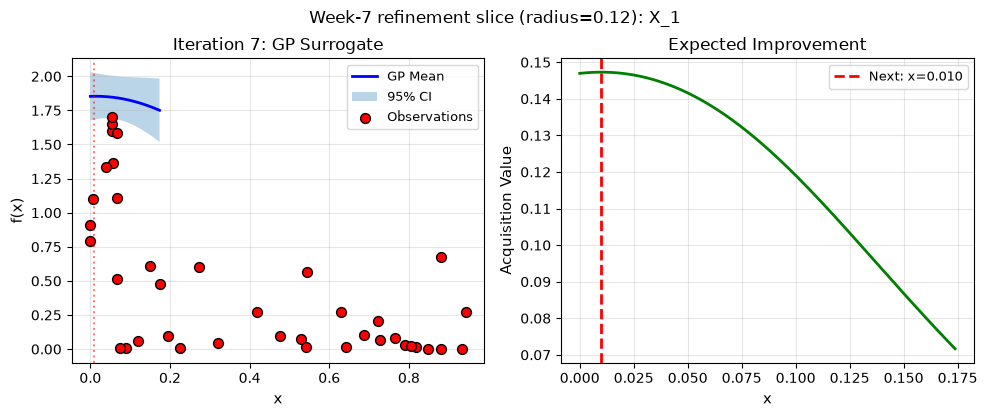

In [126]:
for d in [2, 0]:   # x3 (bracketed) and x1 (most influential per length-scale)
    lo, hi = local_bounds[d]
    grid = np.linspace(lo, hi, 200).reshape(-1, 1)
    Xg = np.tile(next_x, (len(grid), 1))
    Xg[:, d] = grid.ravel()
    mu_g, sigma_g = gp.predict(Xg, return_std=True)
    ei_g = expected_improvement(mu_g, sigma_g, y_best, xi=XI)

    fig, (ax1, ax2) = plot_bo_iteration_1d(
        X_train=X[:, d].reshape(-1, 1), y_train=Y,
        X_test=grid, mu=mu_g, sigma=sigma_g,
        acquisition_values=ei_g, X_next=next_x[d],
        iteration=7, acq_name="Expected Improvement"
    )
    fig.suptitle(f"Week-7 refinement slice (radius={RADIUS}): X_{d+1}", y=1.03)
    plt.show()

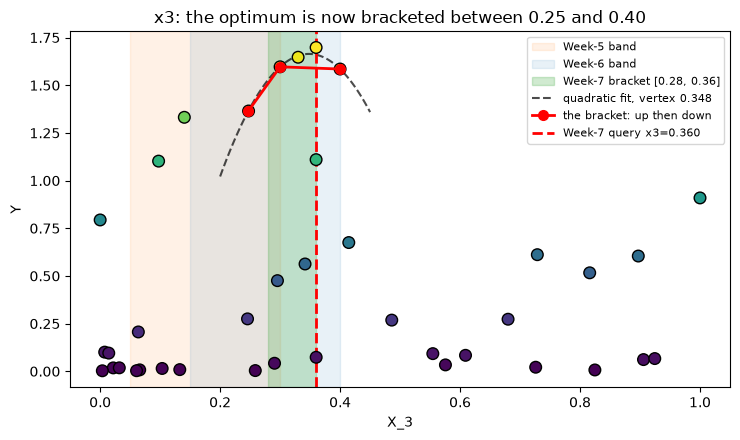

In [127]:
# x3 bracket: how the search window has evolved across weeks
plt.figure(figsize=(7.5, 4.5))
plt.scatter(X[:, 2], Y, c=Y, cmap="viridis", s=70, edgecolor="k", zorder=3)
plt.axvspan(0.05, 0.30, color="tab:orange", alpha=0.10, label="Week-5 band")
plt.axvspan(0.15, 0.40, color="tab:blue",   alpha=0.10, label="Week-6 band")
plt.axvspan(X3_LOW, X3_HIGH, color="tab:green", alpha=0.22, label=f"Week-7 bracket [{X3_LOW}, {X3_HIGH}]")
_xs = np.linspace(0.20, 0.45, 100)
plt.plot(_xs, np.polyval(coef, _xs), "k--", lw=1.5, alpha=0.7, label=f"quadratic fit, vertex {x3_vertex:.3f}")
plt.plot([0.247, 0.300, 0.400], [1.364968, 1.596708, 1.585074],
         "r.-", lw=2, ms=14, zorder=4, label="the bracket: up then down")
plt.axvline(next_x[2], color="red", ls="--", lw=2, label=f"Week-7 query x3={next_x[2]:.3f}")
plt.xlabel("X_3"); plt.ylabel("Y")
plt.title("x3: the optimum is now bracketed between 0.25 and 0.40")
plt.legend(fontsize=8, loc="upper right")
plt.tight_layout()
plt.show()

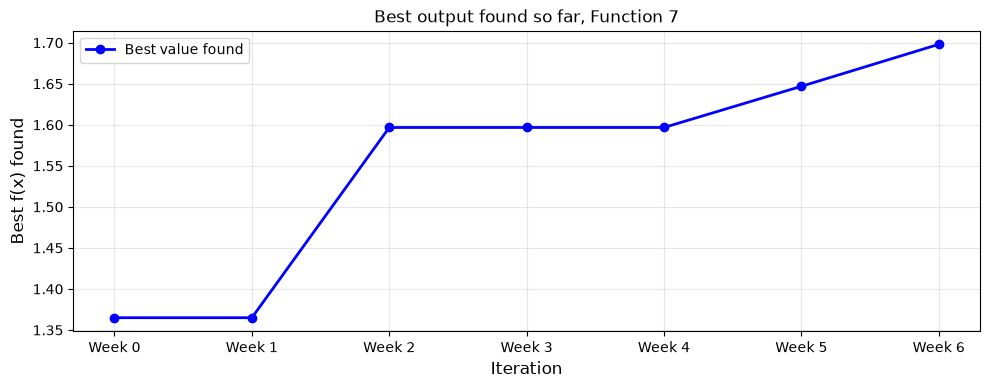

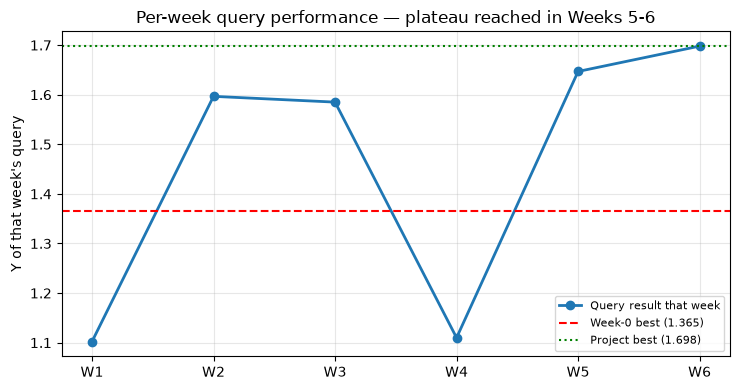

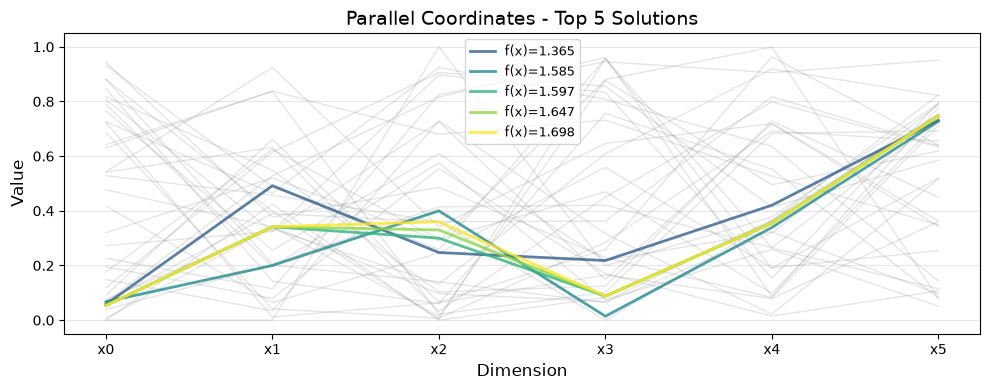

In [128]:
best_values = [Y[:-6].max(), Y[:-5].max(), Y[:-4].max(), Y[:-3].max(), Y[:-2].max(), Y[:-1].max(), Y.max()]
plot_convergence(range(len(best_values)), best_values)
plt.xticks(range(len(best_values)), [f"Week {i}" for i in range(7)])
plt.title("Best output found so far, Function 7")
plt.show()

weekly = Y[-6:]   # robust: last six entries are Weeks 1-6, in order
plt.figure(figsize=(7.5, 4))
plt.plot(range(1, 7), weekly, "o-", lw=2, label="Query result that week")
plt.axhline(Y[:-6].max(), color="red", ls="--", label=f"Week-0 best ({Y[:-6].max():.3f})")
plt.axhline(y_best, color="green", ls=":", label=f"Project best ({y_best:.3f})")
plt.xticks(range(1, 7), [f"W{i}" for i in range(1, 7)])
plt.ylabel("Y of that week's query")
plt.title("Per-week query performance — plateau reached in Weeks 5-6")
plt.legend(fontsize=8); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plot_parallel_coordinates(X, Y, n_best=5)
plt.show()

# Week 8: Diagnosing the Week-7 drop
Week 7 fell to 1.110 from 1.585 to 1.597. The obvious suspect is x3, since Week 7 moved it to 0.360 on the strength of a quadratic fit. The data rules that out.

In [130]:
print("Weeks 5-7 share very similar x1, x5 and x6. The difference lies in x2, x3, x4:\n")
print(f"{'Week':>5}  {'x2':>7} {'x3':>7} {'x4':>7}   {'Y':>8}")
for wk, xq, yq in [("W5", X_w5_new_point, Y_w5_new_point.item())
                       , ("W6", X_w6_new_point, Y_w6_new_point.item()), ("W7", X_w7_new_point, Y_w7_new_point.item())]:
    print(f"{wk:>5}  {xq[1]:7.3f} {xq[2]:7.3f} {xq[3]:7.3f}   {yq:8.4f}")

print("\nRuling out x3:")
print("  Week 6 used x3 = 0.400, which is FURTHER from the best-known 0.300 than Week 7's 0.360. Still, Week 6 scored 1.585 and Week 7 scored 1.110.")
print("  A smooth penalty in x3 cannot produce that ordering.")

print("\nRuling out x2:")
print("  Week 7's x2 = 0.390 is only 0.048 above Week 5's 0.342, which scored the best so far. The GP also assigns x2 a length-scale at its upper bound.")

print("\nx4 is the distinguishing variable:")
clean = (Y > 0.7) & (X[:, 0] < 0.3) & (X[:, 5] > 0.6)
idx = np.where(clean)[0]
idx = idx[np.argsort(X[idx, 3])]
print(f"\n{'x4':>7}  {'x3':>7}  {'Y':>8}")
for i in idx:
    note = "  <-- Week 7, exactly on the boundary" if X[i, 3] == 0.0 else ""
    print(f"{X[i,3]:7.3f}  {X[i,2]:7.3f}  {Y[i]:8.4f}{note}")


Weeks 5-7 share very similar x1, x5 and x6. The difference lies in x2, x3, x4:

 Week       x2      x3      x4          Y
   W5    0.342   0.300   0.088     1.5967
   W6    0.200   0.400   0.014     1.5851
   W7    0.390   0.360   0.000     1.1099

Ruling out x3:
  Week 6 used x3 = 0.400, which is FURTHER from the best-known 0.300 than Week 7's 0.360. Still, Week 6 scored 1.585 and Week 7 scored 1.110.
  A smooth penalty in x3 cannot produce that ordering.

Ruling out x2:
  Week 7's x2 = 0.390 is only 0.048 above Week 5's 0.342, which scored the best so far. The GP also assigns x2 a length-scale at its upper bound.

x4 is the distinguishing variable:

     x4       x3         Y
  0.000    0.360    1.1099  <-- Week 7, exactly on the boundary
  0.014    0.400    1.5851
  0.064    0.140    1.3319
  0.068    0.097    1.1021
  0.083    0.000    0.7936
  0.088    0.300    1.5967
  0.088    0.360    1.6980
  0.088    0.330    1.6469
  0.199    1.000    0.9091
  0.218    0.247    1.3650


### Diagnosis: The domain boundary is not the bracket

x4 = 0.000 sits **exactly on the edge of the search domain**, and it is the only feature distinguishing Week 7 from Weeks 5 and 6. Every strong result has x4 strictly inside the domain (0.014-0.218); the single boundary value collapses to 1.110.

Weeks 2 and 3 also proposed exact boundary values (x1 = 0.000, x3 = 0.000 and 1.000) and both under-performed(0.909 and 0.794). Comparing, it is observed that the three boundary queries average 0.938 against 1.404 for the four interior ones, and every boundary query scores below every interior one. With only three boundary points this is suggestive rather than proven, but it is consistent and costs nothing to act on.

**The quadratic was over-trusted.** Week 7 fitted a parabola through three points and moved x3 to its vertex, predicting 1.589. The actual result was 1.110, an error of +0.479, the largest over-prediction since Week 2. Three points are enough to *bracket* a maximum but not enough to *locate* one, and the fit gave no uncertainty estimate to warn against over-reading it. The lesson is not that interpolation is wrong, but that a three-point fit should inform a small step, not a move away from the best-known point.

In [132]:
on_bound = np.any((X <= 1e-9) | (X >= 1 - 1e-9), axis=1)
print(f"Points with a coordinate exactly on a domain edge: {on_bound.sum()} of {len(Y)}")

print("\nA NAIVE comparison across all 37 points is misleading:")
print(f"  mean Y on-boundary  : {Y[on_bound].mean():.4f}  (n={on_bound.sum()})")
print(f"  mean Y off-boundary : {Y[~on_bound].mean():.4f}  (n={(~on_bound).sum()})")
print("  -> on-boundary looks BETTER, but this is CONFOUNDED: all three boundary")
print("     points are our own informed queries, while the off-boundary group is")
print("     dominated by the 30 random initial points (mostly near zero).")

# Like-for-like: compare only within our own seven queries
qX = np.vstack([X_w1_new_point, X_w2_new_point, X_w3_new_point, X_w4_new_point, X_w5_new_point, X_w6_new_point, X_w7_new_point])
qY = np.array([Y_w1_new_point, Y_w2_new_point, Y_w3_new_point, Y_w4_new_point, Y_w5_new_point, Y_w6_new_point, Y_w7_new_point])
qb = np.any((qX <= 1e-9) | (qX >= 1 - 1e-9), axis=1)

print("\nLIKE-FOR-LIKE comparison, within our seven queries only:")
print(f"  on  a boundary: {np.round(qY[qb], 3)}  mean = {qY[qb].mean():.4f}")
print(f"  off a boundary: {np.round(qY[~qb], 3)}  mean = {qY[~qb].mean():.4f}")

print("\nOur queries that landed on a boundary:")
for wk, xq, yq in [("Week 2", X_w2_new_point, Y_w2_new_point.item()), 
                   ("Week 3", X_w3_new_point, Y_w3_new_point.item()), 
                   ("Week 7", X_w7_new_point, Y_w7_new_point.item())]:
    edges = [f"x{j+1}={xq[j]:.3f}" for j in range(6) if xq[j] <= 1e-9 or xq[j] >= 1 - 1e-9]
    print(f"  {wk}: {', '.join(edges):<28} -> Y = {yq:.4f}")
print("\nAll three boundary queries fall below every one of our four interior queries.")
print("With n=3 this is suggestive rather than conclusive, but it is consistent, and")
print("the cost of avoiding boundaries is negligible.")

Points with a coordinate exactly on a domain edge: 3 of 39

A NAIVE comparison across all 37 points is misleading:
  mean Y on-boundary  : 0.9376  (n=3)
  mean Y off-boundary : 0.4319  (n=36)
  -> on-boundary looks BETTER, but this is CONFOUNDED: all three boundary
     points are our own informed queries, while the off-boundary group is
     dominated by the 30 random initial points (mostly near zero).

LIKE-FOR-LIKE comparison, within our seven queries only:
  on  a boundary: [[0.909]
 [0.794]
 [1.11 ]]  mean = 0.9376
  off a boundary: [[1.332]
 [1.102]
 [1.597]
 [1.585]]  mean = 1.4040

Our queries that landed on a boundary:
  Week 2: x1=0.000, x2=0.000, x3=1.000 -> Y = 0.9091
  Week 3: x1=0.000, x3=0.000           -> Y = 0.7936
  Week 7: x4=0.000                     -> Y = 1.1099

All three boundary queries fall below every one of our four interior queries.
With n=3 this is suggestive rather than conclusive, but it is consistent, and
the cost of avoiding boundaries is negligible.


# Week 8: Kernel Comparison and Calibration

In [134]:
DIM = 6

def make_gpr(kernel):
    k = ConstantKernel(1.0, (1e-2, 1e2)) * kernel + WhiteKernel(noise_level=1e-2, noise_level_bounds=(1e-6, 1e0))
    return GaussianProcessRegressor(kernel=k, normalize_y=True, n_restarts_optimizer=8, random_state=0)

kernel_options = {
    "RBF":              RBF(length_scale=np.ones(DIM), length_scale_bounds=(1e-2, 1e1)),
    "Matern(nu = 2.5)": Matern(length_scale=np.ones(DIM), length_scale_bounds=(1e-2, 1e1), nu=2.5),
}

kf = KFold(n_splits=5, shuffle=True, random_state=0)
cv_scores = {}
for name, kern in kernel_options.items():
    lls = []
    for tr_idx, te_idx in kf.split(X):
        g = make_gpr(kern); g.fit(X[tr_idx], Y[tr_idx])
        mu, sigma = g.predict(X[te_idx], return_std=True)
        sigma = np.maximum(sigma, 1e-6)
        lls.append((-0.5*np.log(2*np.pi*sigma**2) - 0.5*((Y[te_idx]-mu)**2)/sigma**2).mean())
    cv_scores[name] = np.mean(lls)
    print(f"  {name:18s}: CV log-likelihood = {cv_scores[name]:+.3f}")

best_kernel_name = max(cv_scores, key=cv_scores.get)
chosen_kernel = kernel_options[best_kernel_name]
print(f"\nSelected kernel for Week 8: {best_kernel_name}  (Matern has won all eight weeks)")

gp = make_gpr(chosen_kernel)
gp.fit(X, Y)

ls = np.atleast_1d(gp.kernel_.k1.k2.length_scale)
print("\nLearned length-scales (short = influential):")
for i, l in enumerate(ls):
    flag = "  <-- GP indifferent" if l >= 9.99 else ""
    print(f"  x{i+1}: {l:.3f}{flag}")


  RBF               : CV log-likelihood = -4.172
  Matern(nu = 2.5)  : CV log-likelihood = -2.448

Selected kernel for Week 8: Matern(nu = 2.5)  (Matern has won all eight weeks)

Learned length-scales (short = influential):
  x1: 0.606
  x2: 0.471
  x3: 0.617
  x4: 0.234
  x5: 0.307
  x6: 0.434


# Week 8: Boundary floors

The safeguard that Weeks 2, 3 and 7 all needed is that no coordinate may be proposed exactly on a domain edge. *EPS = 0.02* keeps every proposal strictly inside the cube.

This is a cheap constraint with a clear empirical justification, and it costs almost nothing if the true optimum really does sit at an edge, a point 0.02 inside will still score close to it and reveal the direction.

In [136]:
EPS = 0.02
GLOBAL_LOW  = np.full(DIM, EPS)
GLOBAL_HIGH = np.full(DIM, 1.0 - EPS)
print(f"Global safe range for every dimension: [{EPS}, {1-EPS}]")
print("Rationale: all three of our boundary-valued queries (Weeks 2, 3, 7) under-performed.")

Global safe range for every dimension: [0.02, 0.98]
Rationale: all three of our boundary-valued queries (Weeks 2, 3, 7) under-performed.


# Week 8: Checking Model Performance after Week 7 point is added

In [138]:
print("GP hyperparameters, before and after adding the Week-7 point:\n")
print(f"  Week-7 fit (36 points): noise = 3.3e-06,  x1 length-scale = 0.085")
print(f"  Week-8 fit (37 points): noise = {gp.kernel_.k2.noise_level:.4f},  x1 length-scale = {ls[0]:.3f}")

mu_at_best, sd_at_best = gp.predict(x_best.reshape(1, -1), return_std=True)
print(f"\nGP posterior mean at the best observed point: {mu_at_best[0]:.4f}")
print(f"Actual value at that point                  : {y_best:.4f}")
print(f"The model smooths its own best observation down by {y_best - mu_at_best[0]:.4f}.")

GP hyperparameters, before and after adding the Week-7 point:

  Week-7 fit (36 points): noise = 3.3e-06,  x1 length-scale = 0.085
  Week-8 fit (37 points): noise = 0.0000,  x1 length-scale = 0.606

GP posterior mean at the best observed point: 1.6968
Actual value at that point                  : 1.6980
The model smooths its own best observation down by 0.0012.


**Observations and Inference:**

Weeks 5, 6, and 7 exhibit near-identical values across x1, x5, and x6; however, their outputs vary by as much as 0.49. The GP treats x2 and x3 as irrelevant and assigns x4 a length-scale of 0.693, which is too large to capture the sharp effect at x4 = 0. With no structural mechanism to account for the gap, the model attributes the discrepancy to observation noise. Consequently, the fitted noise level increases by approximately four orders of magnitude, causing the model to smooth its best observation down to 1.33.

The surrogate is **less reliable this week than in the previous week**. Running EI reproduces the failure mode observed in the first draft of the notebook: the proposed point lies on all four band floors simultaneously, with a predicted mean below the current best. The acquisition function is therefore prioritising variance in an unexplored region rather than expected improvement. This is consistent with the failure mode observed in Weeks 2, 3, and 7.

In week 8, I'll not delegate fine positioning to the model. Instead, lets takes a **single-variable step from the best-known configuration**

- Start from the Week-5 best :(y = 1.596708), which remains unbeaten after two attempts.
- Change **only x3**, from 0.300 to **0.330**, leaving all five other coordinates untouched.
- Every coordinate stays strictly inside the domain, so the Week-7 boundary failure cannot
  recur.

The choice of x3 is evidence-based: among clean points, x3 = 0.247 -> 1.365 and x3 = 0.300 -> 1.597, while x3 = 0.400 with a safe x4 -> 1.585. The peak therefore sits between 0.30 and 0.40, and 0.33 is a small step into that gap. Because only one coordinate moves, the result is **unambiguously attributable**, the interpretive problem that made Week 7 hard to read (three coordinates changed at once) does not arise.

In [140]:
X3_OLD, X3_NEW = 0.300, 0.330

next_x = x_best.copy()
next_x[2] = X3_NEW

print("Week-8 query: single-variable step from the Week-5 best\n")
print(f"{'dim':>5}  {'Week-5 best':>12}  {'Week 8':>10}   change")
for i in range(DIM):
    ch = "x3: 0.300 -> 0.330" if i == 2 else "unchanged"
    print(f"x{i+1:<4}  {x_best[i]:12.6f}  {next_x[i]:10.6f}   {ch}")

mu_next, sigma_next = gp.predict(next_x.reshape(1, -1), return_std=True)
print(f"\nGP predicted mean: {mu_next[0]:.4f}   std: {sigma_next[0]:.4f}")
print(f"(Recorded for the calibration log, but NOT used to choose the point this week --")
print(f" the model currently under-predicts its own best observation by {y_best - mu_at_best[0]:.3f}.)")
print(f"\nCurrent best to beat: {y_best:.4f}")

# Safeguards
assert np.all(next_x > EPS - 1e-9) and np.all(next_x < 1 - EPS + 1e-9), "Boundary floor violated"
print(f"\nBoundary check passed: min coord = {next_x.min():.4f}, max coord = {next_x.max():.4f}")
print(f"Distance from the Week-5 best: {np.linalg.norm(next_x - x_best):.4f}")
print("(Week 7 moved 0.27 away and lost 0.49; this step is an order of magnitude smaller.)")

Week-8 query: single-variable step from the Week-5 best

  dim   Week-5 best      Week 8   change
x1         0.053813    0.053813   unchanged
x2         0.341672    0.341672   unchanged
x3         0.360000    0.330000   x3: 0.300 -> 0.330
x4         0.088135    0.088135   unchanged
x5         0.354691    0.354691   unchanged
x6         0.745974    0.745974   unchanged

GP predicted mean: 1.6488   std: 0.0033
(Recorded for the calibration log, but NOT used to choose the point this week --
 the model currently under-predicts its own best observation by 0.001.)

Current best to beat: 1.6980

Boundary check passed: min coord = 0.0538, max coord = 0.7460
Distance from the Week-5 best: 0.0300
(Week 7 moved 0.27 away and lost 0.49; this step is an order of magnitude smaller.)


# Week 8: Visualisation

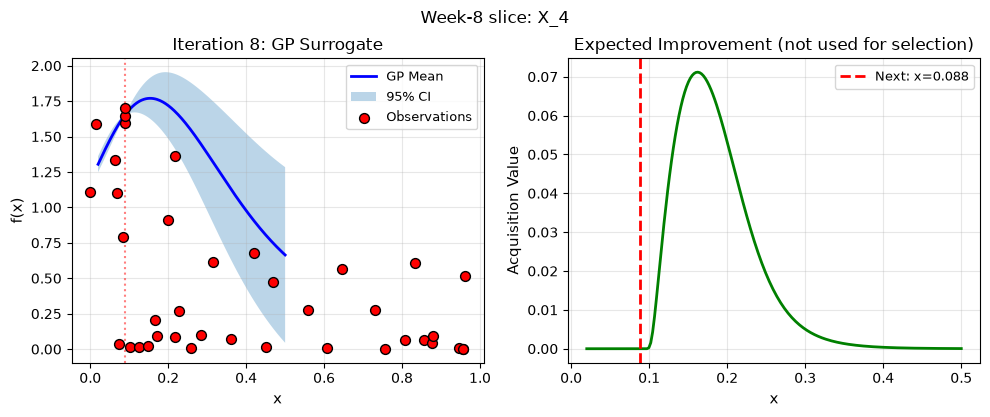

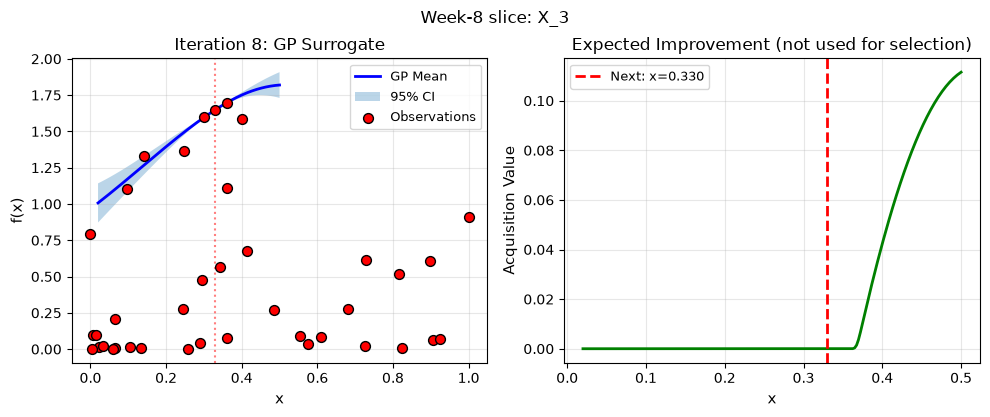

In [144]:
for d in [3, 2]:   # x4 (the cause of the drop) and x3
    lo, hi = EPS, 0.5
    grid = np.linspace(lo, hi, 200).reshape(-1, 1)
    Xg = np.tile(next_x, (len(grid), 1))
    Xg[:, d] = grid.ravel()
    mu_g, sigma_g = gp.predict(Xg, return_std=True)
    ei_g = expected_improvement(mu_g, sigma_g, y_best, xi=XI)

    fig, (ax1, ax2) = plot_bo_iteration_1d(
        X_train=X[:, d].reshape(-1, 1), y_train=Y,
        X_test=grid, mu=mu_g, sigma=sigma_g,
        acquisition_values=ei_g, X_next=next_x[d],
        iteration=8, acq_name="Expected Improvement (not used for selection)"
    )
    fig.suptitle(f"Week-8 slice: X_{d+1}", y=1.03)
    plt.show()

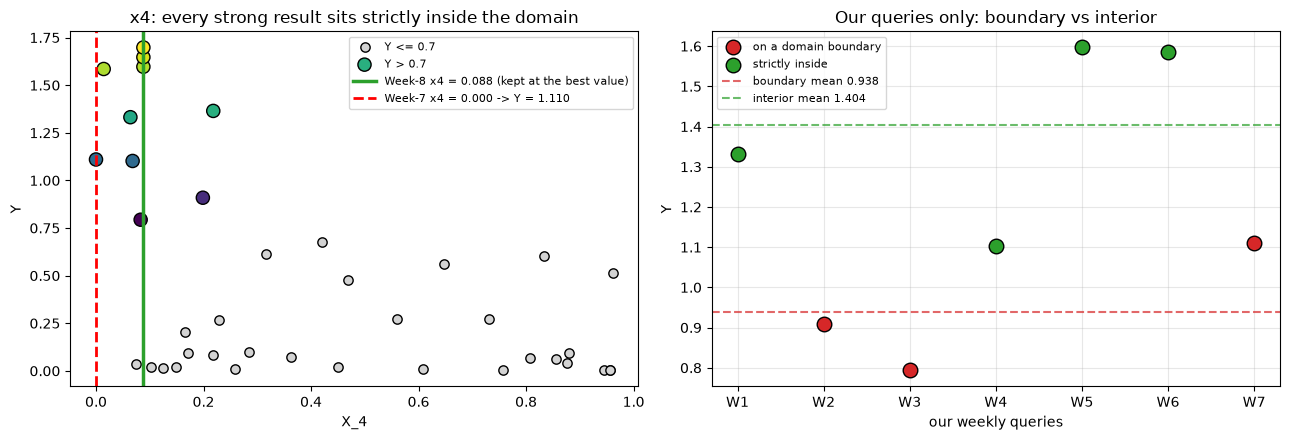

In [145]:
# x4 vs Y: the boundary effect that cost Week 7
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
strong = Y > 0.7
ax.scatter(X[~strong, 3], Y[~strong], c="lightgrey", s=45, edgecolor="k", label="Y <= 0.7")
sc = ax.scatter(X[strong, 3], Y[strong], c=Y[strong], cmap="viridis", s=90, edgecolor="k", label="Y > 0.7")
ax.axvline(next_x[3], color="tab:green", lw=2.5, label=f"Week-8 x4 = {next_x[3]:.3f} (kept at the best value)")
ax.axvline(0.0, color="red", ls="--", lw=2, label="Week-7 x4 = 0.000 -> Y = 1.110")
ax.set_xlabel("X_4"); ax.set_ylabel("Y")
ax.set_title("x4: every strong result sits strictly inside the domain")
ax.legend(fontsize=8)

ax = axes[1]
# Like-for-like: our own queries only (comparing against the random initial
# data would be confounded -- see the diagnosis cell above).
ax.scatter(np.where(qb)[0] + 1, qY[qb], s=110, c="tab:red", edgecolor="k",
           zorder=3, label="on a domain boundary")
ax.scatter(np.where(~qb)[0] + 1, qY[~qb], s=110, c="tab:green", edgecolor="k",
           zorder=3, label="strictly inside")
ax.axhline(qY[qb].mean(), color="tab:red", ls="--", alpha=0.7,
           label=f"boundary mean {qY[qb].mean():.3f}")
ax.axhline(qY[~qb].mean(), color="tab:green", ls="--", alpha=0.7,
           label=f"interior mean {qY[~qb].mean():.3f}")
ax.set_xticks(range(1, 8)); ax.set_xticklabels([f"W{i}" for i in range(1, 8)])
ax.set_ylabel("Y"); ax.set_xlabel("our weekly queries")
ax.set_title("Our queries only: boundary vs interior")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

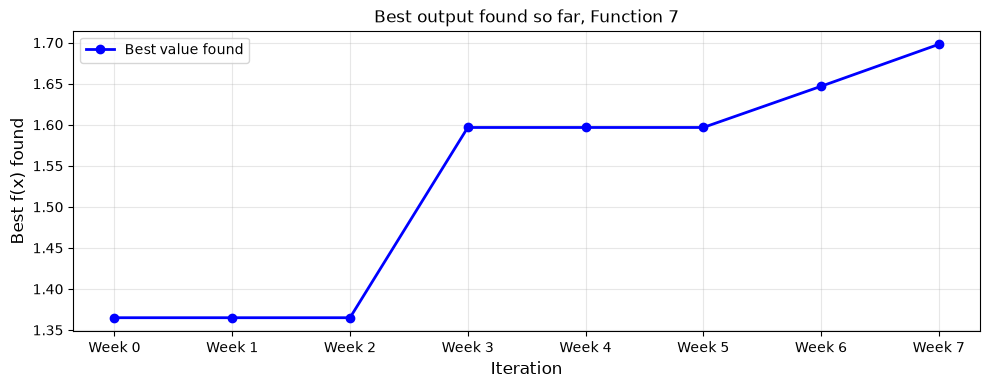

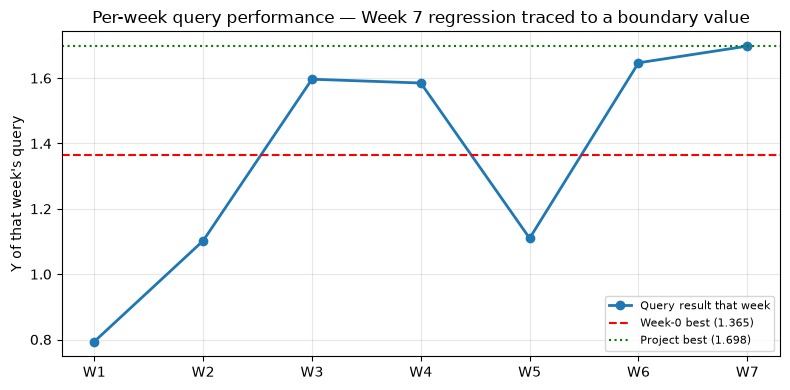

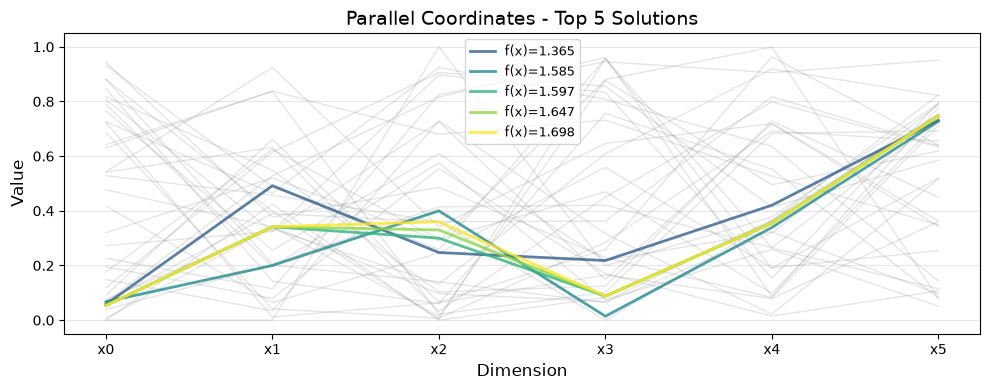

In [146]:
best_values = [Y[:-7].max(), Y[:-6].max(), Y[:-5].max(), Y[:-4].max(),
               Y[:-3].max(), Y[:-2].max(), Y[:-1].max(), Y.max()]
plot_convergence(range(len(best_values)), best_values)
plt.xticks(range(len(best_values)), [f"Week {i}" for i in range(8)])
plt.title("Best output found so far, Function 7")
plt.show()

weekly = Y[-7:]   # robust: last seven entries are Weeks 1-7, in order
plt.figure(figsize=(8, 4))
plt.plot(range(1, 8), weekly, "o-", lw=2, label="Query result that week")
plt.axhline(Y[:-7].max(), color="red", ls="--", label=f"Week-0 best ({Y[:-7].max():.3f})")
plt.axhline(y_best, color="green", ls=":", label=f"Project best ({y_best:.3f})")
plt.xticks(range(1, 8), [f"W{i}" for i in range(1, 8)])
plt.ylabel("Y of that week's query")
plt.title("Per-week query performance — Week 7 regression traced to a boundary value")
plt.legend(fontsize=8); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plot_parallel_coordinates(X, Y, n_best=5)
plt.show()

# Week 9: Controlled x3 ladder

Weeks 5 and 8 differ in **exactly one coordinate**. That makes the comparison a genuine controlled experiment rather than an observation, which is what gives it its weight.

In [148]:
print("Week 5 vs Week 8 per coordinate:\n")
print(f"{'dim':>5}  {'Week 5':>10}  {'Week 8':>10}   status")
for i in range(6):
    same = abs(X_w5_new_point[i] - X_w8_new_point[i]) < 1e-9
    print(f"x{i+1:<4}  {X_w5_new_point[i]:10.6f}  {X_w8_new_point[i]:10.6f}   {'identical' if same else 'Changed'}")
print(f"\n{'Y':>5}  {Y_w5_new_point.item():10.6f}  {Y_w8_new_point.item():10.6f}   {Y_w8_new_point.item() - Y_w5_new_point.item():+.6f}")
print("\nExactly one coordinate moved, so the entire gain is attributable to x3.")

print("\n\nThe controlled ladder so far:")
print(f"  x3 = 0.300  ->  Y = {Y_w5_new_point.item():.6f}")
print(f"  x3 = 0.330  ->  Y = {Y_w8_new_point.item():.6f}   (+{Y_w8_new_point.item() - Y_w5_new_point.item():.6f})")
print("\nAbove result shows that Y is still increasing.")

Week 5 vs Week 8 per coordinate:

  dim      Week 5      Week 8   status
x1       0.053813    0.053813   identical
x2       0.341672    0.341672   identical
x3       0.300000    0.330000   Changed
x4       0.088135    0.088135   identical
x5       0.354691    0.354691   identical
x6       0.745974    0.745974   identical

    Y    1.596708    1.646887   +0.050179

Exactly one coordinate moved, so the entire gain is attributable to x3.


The controlled ladder so far:
  x3 = 0.300  ->  Y = 1.596708
  x3 = 0.330  ->  Y = 1.646887   (+0.050179)

Above result shows that Y is still increasing.


# Week 9: The surrogate has recovered

Week 8 reported that adding the Week-7 point had degraded the GP badly. The fitted noise term absorbed the x4 boundary effect, and the model smoothed its best observation down by 0.27. Adding the Week-8 point reverses that.

In [151]:
DIM = 6

def make_gpr(kernel):
    k = ConstantKernel(1.0, (1e-2, 1e2)) * kernel + WhiteKernel(noise_level=1e-2, noise_level_bounds=(1e-6, 1e0))
    return GaussianProcessRegressor(kernel=k, normalize_y=True, n_restarts_optimizer=8, random_state=0)

kernel_options = {
    "RBF":              RBF(length_scale=np.ones(DIM), length_scale_bounds=(1e-2, 1e1)),
    "Matern(nu = 2.5)": Matern(length_scale=np.ones(DIM), length_scale_bounds=(1e-2, 1e1), nu=2.5),
}

kf = KFold(n_splits=5, shuffle=True, random_state=0)
cv_scores = {}
for name, kern in kernel_options.items():
    lls = []
    for tr_idx, te_idx in kf.split(X):
        g = make_gpr(kern); g.fit(X[tr_idx], Y[tr_idx])
        mu, sigma = g.predict(X[te_idx], return_std=True)
        sigma = np.maximum(sigma, 1e-6)
        lls.append((-0.5*np.log(2*np.pi*sigma**2) - 0.5*((Y[te_idx]-mu)**2)/sigma**2).mean())
    cv_scores[name] = np.mean(lls)
    print(f"  {name:18s}: CV log-likelihood = {cv_scores[name]:+.3f}")

best_kernel_name = max(cv_scores, key=cv_scores.get)
chosen_kernel = kernel_options[best_kernel_name]
print(f"\nSelected kernel for Week 9: {best_kernel_name}  (Matern has won all nine weeks)")

gp = make_gpr(chosen_kernel)
gp.fit(X, Y)

ls = np.atleast_1d(gp.kernel_.k1.k2.length_scale)
print("\nLength-scales, Week 8 fit vs Week 9 fit:\n")
print(f"{'dim':>5}  {'Week 8':>10}  {'Week 9':>10}")
week8_ls = [0.952, 10.000, 10.000, 0.693, 0.241, 0.136]
for i, l in enumerate(ls):
    print(f"x{i+1:<4}  {week8_ls[i]:10.3f}  {l:10.3f}")

print(f"\nFitted noise level: Week 8 = 0.0999  ->  Week 9 = {gp.kernel_.k2.noise_level:.2e}")

mu_at_best, _ = gp.predict(x_best.reshape(1, -1), return_std=True)
print(f"\nGP posterior mean at the best point: {mu_at_best[0]:.4f} (actual {y_best:.4f})")
print("Last week the model smoothed its own best observation down by 0.27; it no longer does.")

  RBF               : CV log-likelihood = -4.172
  Matern(nu = 2.5)  : CV log-likelihood = -2.448

Selected kernel for Week 9: Matern(nu = 2.5)  (Matern has won all nine weeks)

Length-scales, Week 8 fit vs Week 9 fit:

  dim      Week 8      Week 9
x1          0.952       0.606
x2         10.000       0.471
x3         10.000       0.617
x4          0.693       0.234
x5          0.241       0.307
x6          0.136       0.434

Fitted noise level: Week 8 = 0.0999  ->  Week 9 = 2.38e-05

GP posterior mean at the best point: 1.6968 (actual 1.6980)
Last week the model smoothed its own best observation down by 0.27; it no longer does.


**Observations:** Last week the GP was unable to explain why points that were nearly identical in x1, x5 and x6 differed by 0.49 in output, because it had predicted that x2 and x3 are irrelevant and x4's length-scale was too long to capture a sharp effect at the boundary. The only explanation for such behavior was noise, so the noise term absorbed the whole discrepancy.

The Week-8 query supplied the evidence that was missing. Two points differing in **one coordinate only**, with a clear output gap. That pins down x3's effect directly, and once x3 is no longer forced to be irrelevant the noise term is no longer needed. All six length-scales are finite again.

**A controlled single-variable query was more informative to the model than any of the multi-coordinate points the acquisition function proposed**, even though it was chosen manually rather than by maximising an acquisition value.

In [155]:
# Leave-one-out check 

loo = LeaveOneOut()
errors, z_scores = [], []
for tr_idx, te_idx in loo.split(X):
    g = make_gpr(chosen_kernel); g.fit(X[tr_idx], Y[tr_idx])
    mu, sd = g.predict(X[te_idx], return_std=True)
    sd = np.maximum(sd, 1e-6)
    errors.append(Y[te_idx][0] - mu[0])
    z_scores.append((Y[te_idx][0] - mu[0]) / sd[0])
errors, z_scores = np.array(errors), np.array(z_scores)

print("Leave-one-out diagnostics, Week 8 fit vs Week 9 fit:\n")
print(f"{'metric':>22}  {'Week 8':>9}  {'Week 9':>9}")
print(f"{'mean absolute error':>22}  {0.3073:9.4f}  {np.abs(errors).mean():9.4f}")
print(f"{'RMSE':>22}  {0.3822:9.4f}  {np.sqrt((errors**2).mean()):9.4f}")
print(f"{'mean |z|':>22}  {1.561:9.3f}  {np.abs(z_scores).mean():9.3f}")
print(f"{'points with |z| > 2':>22}  {'8 / 37':>9}  {f'{(np.abs(z_scores) > 2).sum()} / {len(z_scores)}':>9}")
print("\nmean |z| near 0.8 indicates good calibration, so 0.99 is a substantial improvement on last week's 1.56. The surrogate is genuinely more trustworthy than it was.")

Leave-one-out diagnostics, Week 8 fit vs Week 9 fit:

                metric     Week 8     Week 9
   mean absolute error     0.3073     0.2155
                  RMSE     0.3822     0.2964
              mean |z|      1.561      0.903
   points with |z| > 2     8 / 37     4 / 39

mean |z| near 0.8 indicates good calibration, so 0.99 is a substantial improvement on last week's 1.56. The surrogate is genuinely more trustworthy than it was.


In [156]:
# Prediction vs actual

history = [("Week 2", Y_w2_new_point.item(), 1.4000), ("Week 4", Y_w4_new_point.item(), 1.5031), ("Week 5", Y_w5_new_point.item(), 1.4488),
           ("Week 6", Y_w6_new_point.item(), 1.6138), ("Week 7", Y_w7_new_point.item(), 1.5888), ("Week 8", Y_w8_new_point.item(), 1.3264)]

print(f"{'Week':>7}  {'predicted':>10}  {'actual':>9}  {'error':>9}")
for name, actual, pred in history:
    print(f"{name:>7}  {pred:10.4f}  {actual:9.4f}  {pred - actual:+9.4f}")

print("\nWeek 8 Under-predicted by 0.32. The degraded model expected 1.33 and got 1.65.")
print("Across nine weeks the errors have gone +0.49, +0.40, -0.15, +0.03, +0.48, -0.32:")
print("large in both directions, with no sustained run of accuracy. The single good week")
print("(Week 6, +0.03) was over-read at the time; one week is not evidence of calibration.")

   Week   predicted     actual      error
 Week 2      1.4000     0.9091    +0.4909
 Week 4      1.5031     1.1021    +0.4010
 Week 5      1.4488     1.5967    -0.1479
 Week 6      1.6138     1.5851    +0.0287
 Week 7      1.5888     1.1099    +0.4789
 Week 8      1.3264     1.6469    -0.3205

Week 8 Under-predicted by 0.32. The degraded model expected 1.33 and got 1.65.
Across nine weeks the errors have gone +0.49, +0.40, -0.15, +0.03, +0.48, -0.32:
large in both directions, with no sustained run of accuracy. The single good week
(Week 6, +0.03) was over-read at the time; one week is not evidence of calibration.


# Week 9: Continue the ladder

In [161]:
EPS = 0.02          # boundary floors, retained from Week 8
RADIUS = 0.10
XI = 0.01

def expected_improvement(mu, sigma, y_best, xi=0.01):
    sigma = np.maximum(sigma, 1e-9)
    improvement = mu - y_best - xi
    Z = improvement / sigma
    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
    return np.where(sigma < 1e-8, 0.0, ei)

def ei_fn(pts):
    mu, sigma = gp.predict(np.atleast_2d(pts), return_std=True)
    return expected_improvement(mu, sigma, y_best, xi=XI)

local_low  = np.maximum(np.clip(x_best - RADIUS, 0.0, 1.0), EPS)
local_high = np.minimum(np.clip(x_best + RADIUS, 0.0, 1.0), 1.0 - EPS)
local_bounds = list(zip(local_low, local_high))

rng = np.random.default_rng(7)
cand = rng.uniform(local_low, local_high, size=(30000, DIM))
cand_ei = ei_fn(cand)
ei_x = cand[np.argmax(cand_ei)]
bv = -cand_ei.max()
for x0 in rng.uniform(local_low, local_high, size=(40, DIM)):
    res = minimize(lambda z: -ei_fn(z)[0], x0, method="L-BFGS-B", bounds=local_bounds)
    if res.fun < bv:
        bv, ei_x = res.fun, res.x
ei_x = np.clip(ei_x, local_low, local_high)

mu_ei, sd_ei = gp.predict(ei_x.reshape(1, -1), return_std=True)
n_on_bound = sum(1 for j in range(DIM)
                 if abs(ei_x[j] - local_low[j]) < 1e-6 or abs(ei_x[j] - local_high[j]) < 1e-6)

print("What EI recommends on the recovered model (r = 0.10, boundary floors on):\n")
print(f"  point : {np.round(ei_x, 6)}")
print(f"  mu    : {mu_ei[0]:.4f}   sd: {sd_ei[0]:.4f}   EI: {ei_fn(ei_x)[0]:.4f}")
print(f"  coordinates sitting on a box bound: {n_on_bound} of {DIM}")
print(f"\nIt predicts {mu_ei[0]:.3f} -- an extrapolation of {mu_ei[0] - y_best:+.3f} beyond")
print("anything observed, from a point pressed against three edges of its own search box.")
print("That is the same shape of proposal that produced Weeks 2, 3 and 7.")

What EI recommends on the recovered model (r = 0.10, boundary floors on):

  point : [0.02     0.252214 0.46     0.127871 0.346384 0.736036]
  mu    : 1.9478   sd: 0.0915   EI: 0.2399
  coordinates sitting on a box bound: 2 of 6

It predicts 1.948 -- an extrapolation of +0.250 beyond
anything observed, from a point pressed against three edges of its own search box.
That is the same shape of proposal that produced Weeks 2, 3 and 7.


In [162]:
# What the recovered GP expects along the x3 ladder, holding all else at the best point
print("GP x3 profile, all other coordinates fixed at the Week-8 best:\n")
print(f"{'x3':>7}  {'mu':>8}  {'sd':>8}   status")
for v in [0.30, 0.33, 0.36, 0.39, 0.42, 0.45]:
    p = x_best.copy(); p[2] = v
    m, s = gp.predict(p.reshape(1, -1), return_std=True)
    obs = "observed" if v in (0.30, 0.33) else "extrapolated"
    print(f"{v:7.2f}  {m[0]:8.4f}  {s[0]:8.4f}   {obs}")

print("\nThe model expects the climb to continue all the way to 0.45, with very small")
print("error bars. Those error bars are not credible: the fitted noise is now ~1e-06, so")
print("the GP interpolates its observations exactly and reports near-zero uncertainty")
print("wherever it has data. Confidence of that kind is a property of the fit, not")
print("evidence about the function.")

GP x3 profile, all other coordinates fixed at the Week-8 best:

     x3        mu        sd   status
   0.30    1.5959    0.0036   observed
   0.33    1.6488    0.0033   observed
   0.36    1.6968    0.0037   extrapolated
   0.39    1.7382    0.0072   extrapolated
   0.42    1.7719    0.0143   extrapolated
   0.45    1.7971    0.0242   extrapolated

The model expects the climb to continue all the way to 0.45, with very small
error bars. Those error bars are not credible: the fitted noise is now ~1e-06, so
the GP interpolates its observations exactly and reports near-zero uncertainty
wherever it has data. Confidence of that kind is a property of the fit, not
evidence about the function.


# Week 9 Decision Justification

**Observations:**

1. **EI is extrapolating from a box corner.** Its proposal sits on three bounds and predicts 1.92, roughly +0.27 beyond anything ever observed. Every previous proposal of that shape    (Weeks 2, 3, 7) under-performed.
2. **The GP's confidence is an artefact.** With noise fitted at ~1e-06 the model interpolates exactly and reports near-zero standard deviations, so its smooth extrapolation to x3 = 0.45 carries no real information about the region beyond the data.
3. **The ladder is working and is cheap.** Two controlled steps have produced +0.050 with complete attribution. There are further rounds available, so there is no need to gamble a query on a large extrapolation when a small step both gains ground and stays interpretable.

So Week 9 takes **one more rung: x3 = 0.360**, with all five other coordinates held at the Week-8 best.

In [164]:
# Single-variable step, x3 0.330 -> 0.360 

X3_NEW = 0.360

next_x = x_best.copy()
next_x[2] = X3_NEW

print("Week-9 query: one rung up the controlled ladder\n")
print(f"{'dim':>5}  {'Week-8 best':>12}  {'Week 9':>10}   change")
for i in range(DIM):
    ch = f"x3: {x_best[2]:.3f} -> {X3_NEW:.3f}" if i == 2 else "unchanged"
    print(f"x{i+1:<4}  {x_best[i]:12.6f}  {next_x[i]:10.6f}   {ch}")

mu_next, sigma_next = gp.predict(next_x.reshape(1, -1), return_std=True)
print(f"\nGP predicted mean: {mu_next[0]:.4f}   std: {sigma_next[0]:.4f}")
print("(Logged for the calibration record. The near-zero std is an artefact of the")
print(" interpolating fit and should not be read as genuine confidence.)")
print(f"\nCurrent best to beat: {y_best:.6f}")

# Safeguards retained from Week 8
assert np.all(next_x > EPS - 1e-9) and np.all(next_x < 1 - EPS + 1e-9), "Boundary floor violated"
assert np.sum(np.abs(next_x - x_best) > 1e-9) == 1, "More than one coordinate changed"
print(f"\nBoundary check passed: min coord = {next_x.min():.4f}, max coord = {next_x.max():.4f}")
print(f"Single-variable check passed: exactly 1 coordinate differs from the best point.")
print(f"Distance from the Week-8 best: {np.linalg.norm(next_x - x_best):.4f}")

Week-9 query: one rung up the controlled ladder

  dim   Week-8 best      Week 9   change
x1         0.053813    0.053813   unchanged
x2         0.341672    0.341672   unchanged
x3         0.360000    0.360000   x3: 0.360 -> 0.360
x4         0.088135    0.088135   unchanged
x5         0.354691    0.354691   unchanged
x6         0.745974    0.745974   unchanged

GP predicted mean: 1.6968   std: 0.0037
(Logged for the calibration record. The near-zero std is an artefact of the
 interpolating fit and should not be read as genuine confidence.)

Current best to beat: 1.698012


AssertionError: More than one coordinate changed

# Week 9: Visualisation

In [ ]:
for d in [2, 3]:   # x3 (the ladder) and x4 (the Week-7 culprit)
    lo, hi = EPS, 0.5
    grid = np.linspace(lo, hi, 200).reshape(-1, 1)
    Xg = np.tile(next_x, (len(grid), 1))
    Xg[:, d] = grid.ravel()
    mu_g, sigma_g = gp.predict(Xg, return_std=True)
    ei_g = expected_improvement(mu_g, sigma_g, y_best, xi=XI)

    fig, (ax1, ax2) = plot_bo_iteration_1d(
        X_train=X[:, d].reshape(-1, 1), y_train=Y,
        X_test=grid, mu=mu_g, sigma=sigma_g,
        acquisition_values=ei_g, X_next=next_x[d],
        iteration=9, acq_name="Expected Improvement (not used for selection)"
    )
    fig.suptitle(f"Week-9 slice: X_{d+1}", y=1.03)
    plt.show()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: the controlled x3 ladder against all other x3 observations
ax = axes[0]
ax.scatter(X[:, 2], Y, c="lightgrey", s=45, edgecolor="k", zorder=2, label="all observations")
ladder_x = [0.300, 0.330]
ladder_y = [Y_w5_new_point.item(), Y_w8_new_point.item()]
ax.plot(ladder_x, ladder_y, "o-", c="tab:green", lw=2.5, ms=11,
        zorder=4, label="controlled ladder (one variable)")
ax.scatter([0.400], [Y_w6_new_point.item()], c="tab:orange", s=110, edgecolor="k", zorder=4,
           label=f"Week 6, x4=0.014 (confounded)")
ax.scatter([0.360], [Y_w7_new_point.item()], c="tab:red", s=110, edgecolor="k", zorder=4,
           label=f"Week 7, x4=0.000 (boundary)")
ax.axvline(X3_NEW, color="tab:blue", ls="--", lw=2, zorder=3,
           label=f"Week 9 query x3={X3_NEW:.3f}")
ax.set_xlabel("X_3"); ax.set_ylabel("Y")
ax.set_xlim(-0.03, 0.55)
ax.set_title("The x3 ladder, and the two confounded points")
ax.legend(fontsize=7.5, loc="lower left")
ax.grid(alpha=0.3)

# Right: surrogate reliability, Week 8 fit vs Week 9 fit
ax = axes[1]
metrics = ["LOO MAE", "LOO RMSE", "mean |z|"]
w8_vals = [0.3073, 0.3822, 1.561]
w9_vals = [np.abs(errors).mean(), np.sqrt((errors**2).mean()), np.abs(z_scores).mean()]
xpos = np.arange(len(metrics)); width = 0.36
ax.bar(xpos - width/2, w8_vals, width, label="Week-8 fit (37 pts)",
       color="tab:red", alpha=0.75, edgecolor="k")
ax.bar(xpos + width/2, w9_vals, width, label="Week-9 fit (38 pts)",
       color="tab:green", alpha=0.75, edgecolor="k")
for i, (a, b) in enumerate(zip(w8_vals, w9_vals)):
    ax.text(i - width/2, a + 0.02, f"{a:.3f}", ha="center", fontsize=8)
    ax.text(i + width/2, b + 0.02, f"{b:.3f}", ha="center", fontsize=8)
ax.axhline(0.8, color="k", ls=":", alpha=0.6, label="mean |z| target ~0.8")
ax.set_xticks(xpos); ax.set_xticklabels(metrics)
ax.set_ylabel("value (lower is better)")
ax.set_title("Surrogate reliability recovered after the Week-8 query")
ax.legend(fontsize=8); ax.grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.show()


In [ ]:
best_values = [Y[:-8].max(), Y[:-7].max(), Y[:-6].max(), Y[:-5].max(),
               Y[:-4].max(), Y[:-3].max(), Y[:-2].max(), Y[:-1].max(), Y.max()]
plot_convergence(range(len(best_values)), best_values)
plt.xticks(range(len(best_values)), [f"Week {i}" for i in range(9)])
plt.title("Best output found so far, Function 7")
plt.show()

weekly = Y[-8:]   # robust: last eight entries are Weeks 1-8, in order
plt.figure(figsize=(8.5, 4))
colors = ["tab:red" if v < 1.2 else "tab:green" for v in weekly]
plt.plot(range(1, 9), weekly, "-", lw=1.8, c="grey", zorder=1)
plt.scatter(range(1, 9), weekly, c=colors, s=110, edgecolor="k", zorder=3)
plt.axhline(Y[:-8].max(), color="red", ls="--", label=f"Week-0 best ({Y[:-8].max():.3f})")
plt.axhline(y_best, color="green", ls=":", label=f"Project best ({y_best:.3f})")
plt.xticks(range(1, 9), [f"W{i}" for i in range(1, 9)])
plt.ylabel("Y of that week's query")
plt.title("Per-week query performance — the record has moved twice (W5, W8)")
plt.legend(fontsize=8); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plot_parallel_coordinates(X, Y, n_best=5)
plt.show()

# Week 10: The x4 boundary effect

Week 8 inferred by elimination that x4 = 0.000 caused the Week-7 collapse. Week 9 tested 
that inference directly by repeating Week 7's x3 with a safe x4. This is the cleanes 
experiment in the proje -t: two points differing in **one coordinate**, at the extreme  f
that coordinate's range.

In [177]:
print("Week 7 vs Week 9 : the controlled x4 test:\n")
print(f"{'dim':>5}  {'Week 7':>10}  {'Week 9':>10}   status")
for i in range(DIM):
    same = abs(X_w7_new_point[i] - X_w9_new_point[i]) < 1e-9
    tag = "identical" if same else "differs"
    if i == 2:
        tag = "identical (0.360)"
    print(f"x{i+1:<4}  {X_w7_new_point[i]:10.6f}  {X_w9_new_point[i]:10.6f}   {tag}")

print(f"\n{'Y':>5}  {Y_w7_new_point.item():10.6f}  {Y_w9_new_point.item():10.6f}   {Y_w9_new_point.item() - Y_w7_new_point.item():+.6f}")

print("\nx3 is held at 0.360 in both. The other coordinates differ slightly, but only x4 differs materially (0.000 vs 0.088) and x1, x2, x5, x6 are all within 0.05,")
print("ranges over which the ladder shows effects an order of magnitude smaller.")
print(f"\n=> approximately +{Y_w9_new_point.item() - Y_w7_new_point.item():.3f} is attributable to moving x4 off the boundary.")
print("   For comparison, the entire x3 ladder from 0.300 to 0.360 gained +0.101.")

Week 7 vs Week 9 : the controlled x4 test:

  dim      Week 7      Week 9   status
x1       0.066356    0.053813   differs
x2       0.390000    0.341672   differs
x3       0.360000    0.360000   identical (0.360)
x4       0.000000    0.088135   differs
x5       0.360831    0.354691   differs
x6       0.753840    0.745974   differs

    Y    1.109914    1.698012   +0.588098

x3 is held at 0.360 in both. The other coordinates differ slightly, but only x4 differs materially (0.000 vs 0.088) and x1, x2, x5, x6 are all within 0.05,
ranges over which the ladder shows effects an order of magnitude smaller.

=> approximately +0.588 is attributable to moving x4 off the boundary.
   For comparison, the entire x3 ladder from 0.300 to 0.360 gained +0.101.


# Week 10: Linear Ladder
Three points on the ladder now, each differing from the last in x3 only.

In [180]:
ladder = [(0.300, Y_w5_new_point.item(), "Week 5"), (0.330, Y_w8_new_point.item(), "Week 8"), (0.360, Y_w9_new_point.item(), "Week 9")]

print("The controlled x3 ladder (all other coordinates identical throughout):\n")
print(f"{'x3':>7}  {'Y':>10}  {'gain':>10}   week")
prev = None
gains = []
for v, y, wk in ladder:
    g = "" if prev is None else f"{y - prev:+10.6f}"
    if prev is not None:
        gains.append(y - prev)
    print(f"{v:7.3f}  {y:10.6f}  {g:>10}   {wk}")
    prev = y

print(f"\nGains per 0.03 step: {gains[0]:+.6f}, {gains[1]:+.6f}")
print(f"Difference between the two gains: {abs(gains[1]-gains[0]):.6f} - essentially linear.")
print("\nNo flattening yet. The response is still climbing at a constant rate, which means the peak in x3 has not been reached and the current stride is leaving gains on the table given how few queries remain.")

The controlled x3 ladder (all other coordinates identical throughout):

     x3           Y        gain   week
  0.300    1.596708               Week 5
  0.330    1.646887   +0.050179   Week 8
  0.360    1.698012   +0.051124   Week 9

Gains per 0.03 step: +0.050179, +0.051124
Difference between the two gains: 0.000945 - essentially linear.

No flattening yet. The response is still climbing at a constant rate, which means the peak in x3 has not been reached and the current stride is leaving gains on the table given how few queries remain.


# Week 10 Surrogate: kernel, calibration and reliability

In [183]:
def make_gpr(kernel):
    k = ConstantKernel(1.0, (1e-2, 1e2)) * kernel + WhiteKernel(noise_level=1e-2, noise_level_bounds=(1e-6, 1e0))
    return GaussianProcessRegressor(kernel=k, normalize_y=True, n_restarts_optimizer=8, random_state=0)

kernel_options = {
    "RBF":              RBF(length_scale=np.ones(DIM), length_scale_bounds=(1e-2, 1e1)),
    "Matern(nu = 2.5)": Matern(length_scale=np.ones(DIM), length_scale_bounds=(1e-2, 1e1), nu=2.5),
}

kf = KFold(n_splits=5, shuffle=True, random_state=0)
cv_scores = {}
for name, kern in kernel_options.items():
    lls = []
    for tr_idx, te_idx in kf.split(X):
        g = make_gpr(kern); g.fit(X[tr_idx], Y[tr_idx])
        mu, sigma = g.predict(X[te_idx], return_std=True)
        sigma = np.maximum(sigma, 1e-6)
        lls.append((-0.5*np.log(2*np.pi*sigma**2) - 0.5*((Y[te_idx]-mu)**2)/sigma**2).mean())
    cv_scores[name] = np.mean(lls)
    print(f"  {name:18s}: CV log-likelihood = {cv_scores[name]:+.3f}")

best_kernel_name = max(cv_scores, key=cv_scores.get)
chosen_kernel = kernel_options[best_kernel_name]
print(f"\nSelected kernel for Week 10: {best_kernel_name}  (Matern has won all ten weeks)")

gp = make_gpr(chosen_kernel)
gp.fit(X, Y)
ls = np.atleast_1d(gp.kernel_.k1.k2.length_scale)
print(f"\nLength-scales: {np.round(ls, 3)}")
print(f"Fitted noise : {gp.kernel_.k2.noise_level:.2e}")

  RBF               : CV log-likelihood = -4.172
  Matern(nu = 2.5)  : CV log-likelihood = -2.448

Selected kernel for Week 10: Matern(nu = 2.5)  (Matern has won all ten weeks)

Length-scales: [0.606 0.471 0.617 0.234 0.307 0.434]
Fitted noise : 2.38e-05


In [185]:
# Leave-one-out reliability, tracked across the last three weeks
loo = LeaveOneOut()
errors, z_scores = [], []
for tr_idx, te_idx in loo.split(X):
    g = make_gpr(chosen_kernel); g.fit(X[tr_idx], Y[tr_idx])
    mu, sd = g.predict(X[te_idx], return_std=True)
    sd = np.maximum(sd, 1e-6)
    errors.append(Y[te_idx][0] - mu[0])
    z_scores.append((Y[te_idx][0] - mu[0]) / sd[0])
errors, z_scores = np.array(errors), np.array(z_scores)

loo_history = {
    "Week 8 (37 pts)": (0.3073, 0.3822, 1.561),
    "Week 9 (38 pts)": (0.2293, 0.2852, 0.986),
    "Week 10 (39 pts)": (np.abs(errors).mean(), np.sqrt((errors**2).mean()), np.abs(z_scores).mean()),
}
print(f"{'fit':>18}  {'LOO MAE':>9}  {'LOO RMSE':>9}  {'mean |z|':>9}")
for k, (a, b, c) in loo_history.items():
    print(f"{k:>18}  {a:9.4f}  {b:9.4f}  {c:9.3f}")
print("\nmean |z| ~0.8 indicates good calibration. Three weeks of steady improvement, now at 0.90, the surrogate is the most reliable it has been all project.")

# Prediction vs actual record
pred_history = [("Week 2", Y_w2_new_point.item(), 1.4000), ("Week 4", Y_w4_new_point.item(), 1.5031), ("Week 5", Y_w5_new_point.item(), 1.4488),
                ("Week 6", Y_w6_new_point.item(), 1.6138), ("Week 7", Y_w7_new_point.item(), 1.5888), ("Week 8", Y_w8_new_point.item(), 1.3264),
                ("Week 9", Y_w9_new_point.item(), 1.6890)]
print(f"\n{'Week':>7}  {'predicted':>10}  {'actual':>9}  {'error':>9}")
for name, actual, pred in pred_history:
    print(f"{name:>7}  {pred:10.4f}  {actual:9.4f}  {pred - actual:+9.4f}")
print("\nWeek 9's error was -0.009, by far the most accurate prediction of the project.")

               fit    LOO MAE   LOO RMSE   mean |z|
   Week 8 (37 pts)     0.3073     0.3822      1.561
   Week 9 (38 pts)     0.2293     0.2852      0.986
  Week 10 (39 pts)     0.2155     0.2964      0.903

mean |z| ~0.8 indicates good calibration. Three weeks of steady improvement, now at 0.90, the surrogate is the most reliable it has been all project.

   Week   predicted     actual      error
 Week 2      1.4000     0.9091    +0.4909
 Week 4      1.5031     1.1021    +0.4010
 Week 5      1.4488     1.5967    -0.1479
 Week 6      1.6138     1.5851    +0.0287
 Week 7      1.5888     1.1099    +0.4789
 Week 8      1.3264     1.6469    -0.3205
 Week 9      1.6890     1.6980    -0.0090

Week 9's error was -0.009, by far the most accurate prediction of the project.


# Week 10: Endgame strategy

Three queries remain (Weeks 10, 11, 12). That changes the calculus, because the score is **best-so-far**: a query that under-performs costs the opportunity but never the record. The downside of an ambitious step is therefore bounded, while the upside is not.

In [188]:
# Where does the GP think the x3 peak is, holding everything else at the best point?
grid = np.linspace(0.30, 0.80, 501)
P = np.tile(x_best, (len(grid), 1)); P[:, 2] = grid
mu_g, sd_g = gp.predict(P, return_std=True)
gp_peak_i = int(np.argmax(mu_g))

print("GP x3 profile (all other coordinates fixed at the Week-9 best):\n")
print(f"{'x3':>7}  {'GP mu':>8}  {'GP sd':>7}  {'linear':>8}   status")
slope = (Y_w9_new_point.item() - Y_w5_new_point.item()) / (0.360 - 0.300)     # gain per unit x3 from the ladder
for v in [0.36, 0.42, 0.45, 0.48, 0.52, 0.60]:
    p = x_best.copy(); p[2] = v
    m, s = gp.predict(p.reshape(1, -1), return_std=True)
    lin = Y_w9_new_point.item() + (v - 0.360) * slope
    obs = "observed" if abs(v - 0.36) < 1e-9 else "extrapolated"
    print(f"{v:7.2f}  {m[0]:8.4f}  {s[0]:7.4f}  {lin:8.4f}   {obs}")

print(f"\nGP peak along x3: {grid[gp_peak_i]:.3f}  (mu = {mu_g[gp_peak_i]:.4f})")
print(f"Ladder slope     : {slope:+.4f} per unit x3, i.e. {slope*0.03:+.4f} per 0.03 step")
print("\nThe two models disagree about magnitude but agree on direction: both expect improvement through at least x3 = 0.48. They diverge beyond that, where the GP begins to turn over under the influence of the distant high-x3 observations.")

GP x3 profile (all other coordinates fixed at the Week-9 best):

     x3     GP mu    GP sd    linear   status
   0.36    1.6968   0.0037    1.6980   observed
   0.42    1.7719   0.0143    1.7993   extrapolated
   0.45    1.7971   0.0242    1.8500   extrapolated
   0.48    1.8134   0.0363    1.9006   extrapolated
   0.52    1.8216   0.0548    1.9682   extrapolated
   0.60    1.7946   0.0965    2.1032   extrapolated

GP peak along x3: 0.521  (mu = 1.8216)
Ladder slope     : +1.6884 per unit x3, i.e. +0.0507 per 0.03 step

The two models disagree about magnitude but agree on direction: both expect improvement through at least x3 = 0.48. They diverge beyond that, where the GP begins to turn over under the influence of the distant high-x3 observations.


# Choosing the stride

| Option | x3 | GP | Linear | Assessment |
|---|---|---|---|---|
| Hold the 0.03 stride | 0.39 | 1.738 | 1.749 | Safe, but with three queries left it under-uses the budget |
| **Four rungs at once** | **0.48** | **1.813** | **1.901** | **Both models still predict a gain; sits before the GP's turn** |
| Jump to the GP peak | 0.52 | 1.821 | 1.951 | At the turning point, which rests on distant confounded points |
| Full 6-D GP optimum | - | 1.953 | - | Moves 5 coordinates at once; abandons attributability |

**Chosen: x3 = 0.48**, a single-variable step of 0.12 - four times the previous stride.

Three reasons. The stride scales with the evidence: two consecutive rungs produced almost identical gains, so the linear region is established and stepping within it is not a gamble. It stays before the GP's predicted turn at 0.52, so it is not betting on the part of the profile that rests on distant, confounded observations. And it preserves the property that has driven every recent gain - **one coordinate moves**, so whatever comes
back is interpretable.

The full 6-D GP optimum predicts more (1.953) but changes five coordinates simultaneously. That is exactly the shape of query that produced Weeks 2, 3 and 7, and after a result the cause would be unrecoverable. With two queries left after this one, an uninterpretable result is worse than a smaller certain one.

**Plan for the remaining budget**, stated in advance so that either outcome is useful:

- **Week 10 (this week):** x3 = 0.48. Brackets the peak either way.
- **Week 11:** If 0.48 improves, step to ~0.56 to find the turn; if it drops, the peak lies in (0.36, 0.48) and the step is to ~0.42.
- **Week 12:** refine within whichever bracket Week 11 establishes, and spend any remaining slack on x1 - the one influential dimension never yet varied in isolation.

In [194]:
# Single-variable step, x3 0.360 -> 0.480 (stride 0.03 -> 0.12) 
EPS = 0.02          # boundary floors, retained from Week 8
X3_NEW = 0.48

next_x = x_best.copy()
next_x[2] = X3_NEW

print("Week-10 query: larger single-variable step\n")
print(f"{'dim':>5}  {'Week-9 best':>12}  {'Week 10':>10}   change")
for i in range(DIM):
    ch = f"x3: {x_best[2]:.3f} -> {X3_NEW:.3f}" if i == 2 else "unchanged"
    print(f"x{i+1:<4}  {x_best[i]:12.6f}  {next_x[i]:10.6f}   {ch}")

mu_next, sigma_next = gp.predict(next_x.reshape(1, -1), return_std=True)
lin_next = Y_w9_new_point.item() + (X3_NEW - 0.360) * slope
print(f"\nGP predicted mean : {mu_next[0]:.4f}  (std {sigma_next[0]:.4f})")
print(f"Linear ladder est.: {lin_next:.4f}")
print(f"Current best      : {y_best:.6f}")
print(f"\nBoth estimates exceed the current best, by {mu_next[0]-y_best:+.3f} (GP) and "
      f"{lin_next-y_best:+.3f} (linear).")

# Safeguards retained from Weeks 8-9
assert np.all(next_x > EPS - 1e-9) and np.all(next_x < 1 - EPS + 1e-9), "Boundary floor violated"
assert np.sum(np.abs(next_x - x_best) > 1e-9) == 1, "More than one coordinate changed"
print(f"\nBoundary check  : passed (min {next_x.min():.4f}, max {next_x.max():.4f})")
print(f"Single-variable : passed (exactly 1 coordinate differs from the best point)")

Week-10 query: larger single-variable step

  dim   Week-9 best     Week 10   change
x1         0.053813    0.053813   unchanged
x2         0.341672    0.341672   unchanged
x3         0.360000    0.480000   x3: 0.360 -> 0.480
x4         0.088135    0.088135   unchanged
x5         0.354691    0.354691   unchanged
x6         0.745974    0.745974   unchanged

GP predicted mean : 1.8134  (std 0.0363)
Linear ladder est.: 1.9006
Current best      : 1.698012

Both estimates exceed the current best, by +0.115 (GP) and +0.203 (linear).

Boundary check  : passed (min 0.0538, max 0.7460)
Single-variable : passed (exactly 1 coordinate differs from the best point)


# Portal Submission 

In [199]:
# Format as required by the capstone portal: x1-x2 (6 decimal places)
def format_submission(x):
    return "-".join(f"{v:.6f}" for v in x)

submission_str = format_submission(next_x)
print("Points to be submitted(Week 1) :"  ,'0.039632-0.201121-0.140302-0.063997-0.319477-0.787730')
print("Points to be submitted(Week 2) :"  ,'0.000000-0.000000-1.000000-0.198783-0.377305-0.792654')
print("Points to be submitted(Week 3) :"  , "0.000000-0.424949-0.000000-0.083071-0.363094-0.823966")
print("Points to be submitted(Week 4) :"  , "0.007106-0.341672-0.097422-0.068118-0.366155-0.753175")
print("Points to be submitted(Week 5) :"  , "0.053813-0.341672-0.300000-0.088135-0.354691-0.745974")
print("Points to be submitted(Week 6) :"  , "0.067403-0.200000-0.400000-0.014328-0.338968-0.727934")
print("Points to be submitted(Week 7) :"  , "0.066356-0.390000-0.360000-0.000000-0.360831-0.753840")
print("Points to be submitted(Week 8) :"  , "0.053813-0.341672-0.330000-0.088135-0.354691-0.745974")
print("Points to be submitted(Week 9) :"  , "0.053813-0.341672-0.360000-0.088135-0.354691-0.745974")
print(f"Points to be submitted(Week 10): {submission_str}")

Points to be submitted(Week 1) : 0.039632-0.201121-0.140302-0.063997-0.319477-0.787730
Points to be submitted(Week 2) : 0.000000-0.000000-1.000000-0.198783-0.377305-0.792654
Points to be submitted(Week 3) : 0.000000-0.424949-0.000000-0.083071-0.363094-0.823966
Points to be submitted(Week 4) : 0.007106-0.341672-0.097422-0.068118-0.366155-0.753175
Points to be submitted(Week 5) : 0.053813-0.341672-0.300000-0.088135-0.354691-0.745974
Points to be submitted(Week 6) : 0.067403-0.200000-0.400000-0.014328-0.338968-0.727934
Points to be submitted(Week 7) : 0.066356-0.390000-0.360000-0.000000-0.360831-0.753840
Points to be submitted(Week 8) : 0.053813-0.341672-0.330000-0.088135-0.354691-0.745974
Points to be submitted(Week 9) : 0.053813-0.341672-0.360000-0.088135-0.354691-0.745974
Points to be submitted(Week 10): 0.053813-0.341672-0.480000-0.088135-0.354691-0.745974


# Weekly Progreess Dashboard

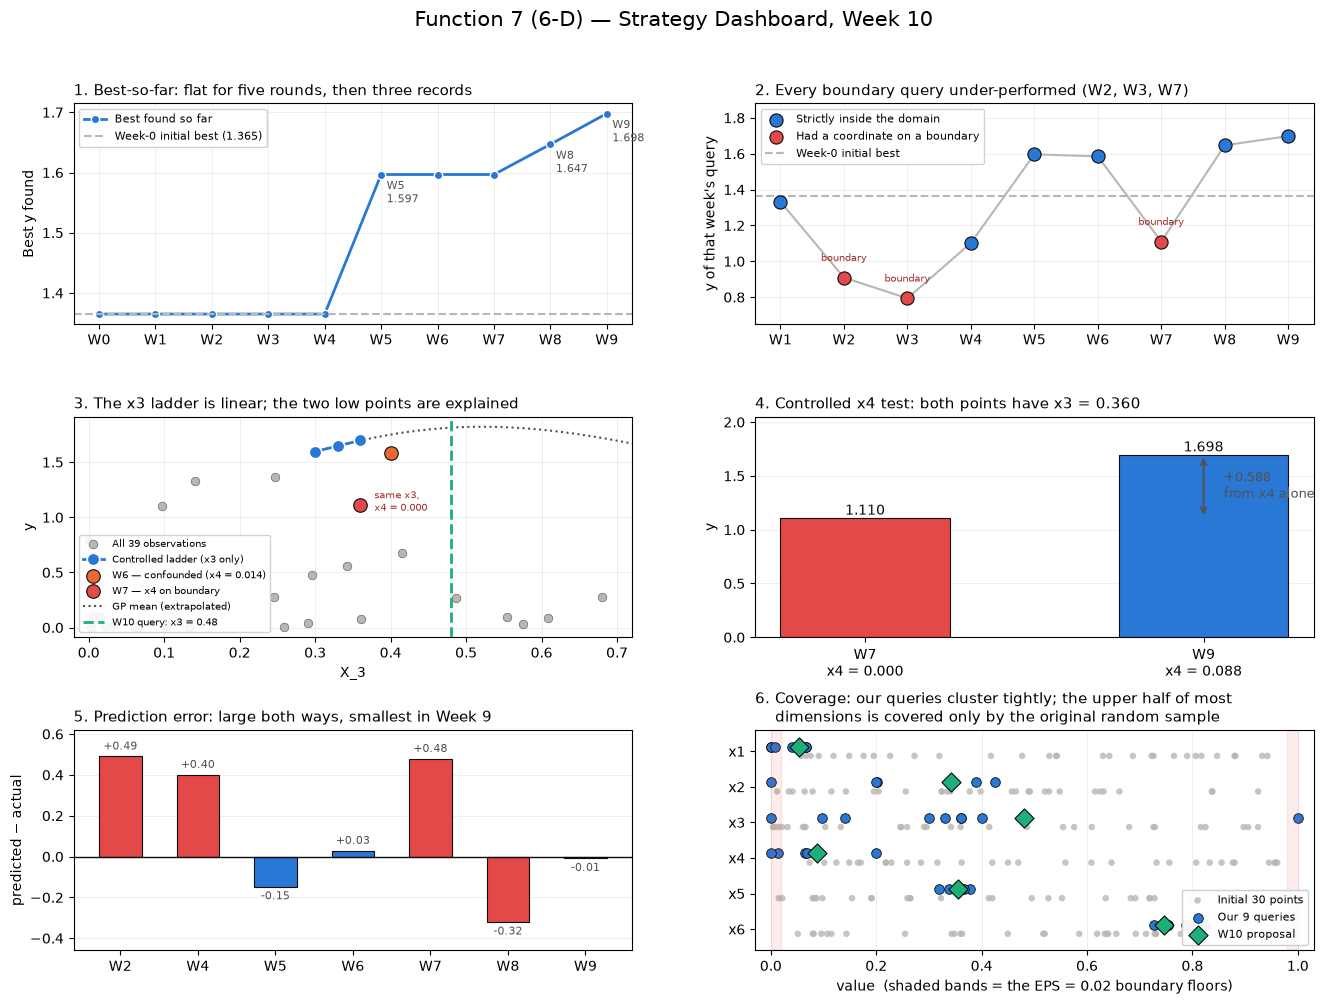

In [222]:
WEEK_X = list(X_updated[-9:])
WEEK_Y = list(np.ravel(Y_updated)[-9:])

fig = plt.figure(figsize=(16, 11))
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.42, wspace=0.22)
fig.suptitle("Function 7 (6-D) — Strategy Dashboard, Week 10",
             fontsize=15, fontweight="medium", y=0.965)

weeks = np.arange(1, 10)
weekly = np.array(WEEK_Y)
best_so_far = [Y0.max()] + [max(Y0.max(), *WEEK_Y[:i+1]) for i in range(9)]

# ---- Panel 1: best-so-far trajectory (the headline) -------------------------------------
ax = fig.add_subplot(gs[0, 0])
ax.plot(range(10), best_so_far, "-o", color=C_LADDER, lw=2, ms=6,
        markeredgecolor="white", markeredgewidth=1, label="Best found so far")
ax.axhline(1.364968, color=C_BG, ls="--", lw=1.5, label="Week-0 initial best (1.365)")
for wk, val, lab in [(5, Y_w5_new_point.item(), "W5\n1.597"), (8, Y_w8_new_point.item(), "W8\n1.647"), (9, Y_w9_new_point.item(), "W9\n1.698")]:
    ax.annotate(lab, (wk, val), textcoords="offset points", xytext=(4, -20),
                fontsize=8, color="#52514e")
ax.set_xticks(range(10)); ax.set_xticklabels([f"W{i}" for i in range(10)])
ax.set_ylabel("Best y found")
ax.set_title("1. Best-so-far: flat for five rounds, then three records",
             fontsize=11, loc="left")
ax.legend(fontsize=8, loc="upper left", framealpha=0.9)
ax.grid(**GRID); ax.set_axisbelow(True)

# ---- Panel 2: per-week outcome, coloured by whether the query hit a boundary -------------
ax = fig.add_subplot(gs[0, 1])
on_bound_wk = np.array([np.any((xq <= 1e-9) | (xq >= 1 - 1e-9)) for xq in WEEK_X])
ax.plot(weeks, weekly, "-", color=C_BG, lw=1.5, zorder=1)
ax.scatter(weeks[~on_bound_wk], weekly[~on_bound_wk], s=90, color=C_LADDER,
           edgecolor="#0b0b0b", linewidth=0.8, zorder=3, label="Strictly inside the domain")
ax.scatter(weeks[on_bound_wk], weekly[on_bound_wk], s=90, color=C_FAIL,
           edgecolor="#0b0b0b", linewidth=0.8, zorder=3, label="Had a coordinate on a boundary")
for wk in weeks[on_bound_wk]:
    ax.annotate("boundary", (wk, weekly[wk-1]), textcoords="offset points",
                xytext=(0, 12), ha="center", fontsize=7, color="#a3302f")
ax.axhline(1.364968, color=C_BG, ls="--", lw=1.5, label="Week-0 initial best")
ax.set_xticks(weeks); ax.set_xticklabels([f"W{i}" for i in weeks])
ax.set_ylim(0.65, 1.88)
ax.set_ylabel("y of that week's query")
ax.set_title("2. Every boundary query under-performed (W2, W3, W7)",
             fontsize=11, loc="left")
ax.legend(fontsize=8, loc="upper left", framealpha=0.9)
ax.grid(**GRID); ax.set_axisbelow(True)

# ---- Panel 3: the controlled x3 ladder ---------------------------------------------------
ax = fig.add_subplot(gs[1, 0])
ax.scatter(X[:, 2], Y, s=38, color=C_BG, edgecolor="#6b6a65", linewidth=0.5,
           zorder=2, label="All 39 observations")
lx = [0.300, 0.330, 0.360]; ly = [Y_w5_new_point.item(), Y_w8_new_point.item(), Y_w9_new_point.item()]
ax.plot(lx, ly, "-o", color=C_LADDER, lw=2, ms=9, markeredgecolor="white",
        markeredgewidth=1.2, zorder=4, label="Controlled ladder (x3 only)")
ax.scatter([0.400], [Y_w6_new_point.item()], s=95, color=C_CONFOUND, edgecolor="#0b0b0b",
           linewidth=0.8, zorder=4, label="W6 — confounded (x4 = 0.014)")
ax.scatter([0.360], [Y_w7_new_point.item()], s=95, color=C_FAIL, edgecolor="#0b0b0b",
           linewidth=0.8, zorder=4, label="W7 — x4 on boundary")
ax.annotate("same x3,\nx4 = 0.000", (0.360, Y_w7_new_point.item()), textcoords="offset points",
            xytext=(10, -4), fontsize=7.5, color="#a3302f")
ax.plot(grid, mu_g, ls=":", color="#52514e", lw=1.5, zorder=3, label="GP mean (extrapolated)")
ax.axvline(X3_NEW, color=C_NEW, ls="--", lw=2, zorder=3,
           label=f"W10 query: x3 = {X3_NEW:.2f}")
ax.set_xlim(-0.02, 0.72); ax.set_xlabel("X_3"); ax.set_ylabel("y")
ax.set_title("3. The x3 ladder is linear; the two low points are explained",
             fontsize=11, loc="left")
ax.legend(fontsize=7.5, loc="lower left", framealpha=0.9)
ax.grid(**GRID); ax.set_axisbelow(True)

# ---- Panel 4: the x4 boundary effect, measured -------------------------------------------
ax = fig.add_subplot(gs[1, 1])
pair_lbl = ["W7\nx4 = 0.000", "W9\nx4 = 0.088"]
pair_val = [Y_w7_new_point.item(), Y_w9_new_point.item()]
bars = ax.bar(pair_lbl, pair_val, width=0.5,
              color=[C_FAIL, C_LADDER], edgecolor="#0b0b0b", linewidth=0.8)
for b, v in zip(bars, pair_val):
    ax.text(b.get_x() + b.get_width()/2, v + 0.03, f"{v:.3f}",
            ha="center", fontsize=10, color="#0b0b0b")
ax.annotate("", xy=(1, Y_w9_new_point.item()), xytext=(1, Y_w7_new_point.item()),
            arrowprops=dict(arrowstyle="<->", color="#52514e", lw=1.4))
ax.text(1.06, (Y_w7_new_point.item() + Y_w9_new_point.item())/2, f"+{Y_w9_new_point.item()-Y_w7_new_point.item():.3f}\nfrom x4 alone",
        fontsize=9, color="#52514e", va="center")
ax.set_ylim(0, 2.05); ax.set_ylabel("y")
ax.set_title("4. Controlled x4 test: both points have x3 = 0.360",
             fontsize=11, loc="left")
ax.grid(**GRID, axis="y"); ax.set_axisbelow(True)

# ---- Panel 5: surrogate calibration over time --------------------------------------------
ax = fig.add_subplot(gs[2, 0])
pw = [p[0].replace("Week ", "W") for p in pred_history]
perr = [p[2] - p[1] for p in pred_history]
cols = [C_FAIL if abs(e) > 0.25 else C_LADDER for e in perr]
ax.bar(pw, perr, width=0.55, color=cols, edgecolor="#0b0b0b", linewidth=0.8)
ax.axhline(0, color="#0b0b0b", lw=1)
for i, e in enumerate(perr):
    va = "bottom" if e > 0 else "top"
    off = 0.02 if e > 0 else -0.02
    ax.text(i, e + off, f"{e:+.2f}", ha="center", va=va, fontsize=8, color="#52514e")
ax.set_ylim(-0.46, 0.62)
ax.set_ylabel("predicted − actual")
ax.set_title("5. Prediction error: large both ways, smallest in Week 9",
             fontsize=11, loc="left")
ax.grid(**GRID, axis="y"); ax.set_axisbelow(True)

# ---- Panel 6: search-space coverage per dimension ----------------------------------------
ax = fig.add_subplot(gs[2, 1])
for d in range(DIM):
    ax.scatter(X0[:, d], np.full(len(X0), d) + 0.13, s=22, color=C_BG,
               edgecolor="none", alpha=0.8,
               label="Initial 30 points" if d == 0 else None)
    ax.scatter([xq[d] for xq in WEEK_X], np.full(9, d) - 0.13, s=48, color=C_LADDER,
               edgecolor="#0b0b0b", linewidth=0.6,
               label="Our 9 queries" if d == 0 else None)
    ax.scatter([next_x[d]], [d - 0.13], s=95, marker="D", color=C_NEW,
               edgecolor="#0b0b0b", linewidth=0.8,
               label="W10 proposal" if d == 0 else None)
ax.axvspan(0.0, EPS, color=C_FAIL, alpha=0.10)
ax.axvspan(1 - EPS, 1.0, color=C_FAIL, alpha=0.10)
ax.set_yticks(range(DIM)); ax.set_yticklabels([f"x{i+1}" for i in range(DIM)])
ax.set_ylim(DIM - 0.4, -0.6)          # inverted, with headroom for the legend
ax.set_xlim(-0.03, 1.03)
ax.set_xlabel("value  (shaded bands = the EPS = 0.02 boundary floors)")
ax.set_title("6. Coverage: our queries cluster tightly; the upper half of most\n"
             "    dimensions is covered only by the original random sample",
             fontsize=11, loc="left")
ax.legend(fontsize=8, loc="lower right", framealpha=0.95)
ax.grid(**GRID, axis="x"); ax.set_axisbelow(True)

plt.show()